In [38]:
pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# Dataset Analysis

In [1]:
from ucimlrepo import fetch_ucirepo
import numpy as np

dataset = fetch_ucirepo(id=891)
# Create pandas DataFrame
df = dataset.data.original

In [52]:
df.dtypes

ID                      int64
Diabetes_binary         int64
HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
dtype: object

In [2]:
df.describe()

,ID,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,126839.500000,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,73231.252481,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,63419.750000,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,126839.500000,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,190259.250000,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,253679.000000,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [3]:
# Separate features and target variable
features = df.drop(columns=["ID", "Diabetes_binary"])
features.dtypes

HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
dtype: object

In [6]:
# float64 In case of ucimlrepo failure, .csv data are float64
numeric_features = features.select_dtypes(["int64"]).columns
FEATURES_NUMBER = len(numeric_features)
print(numeric_features)

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')


In [7]:
# Controlliamo la percentuale di 0 e 1 nel dataset originale
class_distribution = df["Diabetes_binary"].value_counts(normalize=True) * 100
print("Class Distribution:")
print(class_distribution)

Class Distribution:
Diabetes_binary
0    86.066698
1    13.933302
Name: proportion, dtype: float64


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features[numeric_features])
print(scaled_data)

[[ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
  -1.4744874 ]
 [-0.86678537 -0.85818163 -5.07816412 ... -0.33793279  0.96327159
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
   0.93963796]
 ...
 [-0.86678537 -0.85818163  0.19692156 ... -1.97501498 -0.05116153
  -1.95731247]
 [ 1.15368814 -0.85818163  0.19692156 ... -0.33793279 -0.05116153
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008  0.96327159
  -1.95731247]]


## Dataset Splitting

In [11]:
from sklearn.model_selection import train_test_split

# 1. Data Preparation
X = scaled_data
y = df["Diabetes_binary"].values

# Split in Train e Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## Dataset Balancing

Viene costruito un dataset bilanciato selezionando in maniera casuale dalla classe maggioritaria (negativa) lo stesso numero di esempi della classe minoritaria (positiva). Viene eseguito uno shuffle e successivamente uno split 70/30 come precedentemente adottato. Il modello viene addestrato e valutato su un datset più piccolo, in cui entrambe le classi hanno la stessa probabilità, rimuovendo quindi lo sbilanciamento del dataset originale

In [ ]:
def balance_dataset(X, y):

    idx_minority = np.where(y == 1)[0]
    idx_majority = np.where(y == 0)[0]

    n_minority = len(idx_minority)

    idx_majority_downsampled = np.random.choice(
        idx_majority, size=n_minority, replace=False
    )

    idx_balanced = np.concatenate([idx_majority_downsampled, idx_minority])
    np.random.shuffle(idx_balanced)

    return X[idx_balanced], y[idx_balanced]


In [ ]:
# 1. Creazione dataset bilanciato (undersampling su tutto il dataset)
X_bal, y_bal = balance_dataset(X, y)

print("Distribuzione classi nel dataset bilanciato:")
unique, counts = np.unique(y_bal, return_counts=True)
print(dict(zip(unique, counts)))

# 2. Train/test split sul dataset bilanciato
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal
)

print("Distribuzione classi nel Training Set bilanciato:")
unique_tr, counts_tr = np.unique(y_train_bal, return_counts=True)
print(dict(zip(unique_tr, counts_tr)))

print("Distribuzione classi nel Test Set bilanciato:")
unique_te, counts_te = np.unique(y_test_bal, return_counts=True)
print(dict(zip(unique_te, counts_te)))

Distribuzione classi nel dataset bilanciato:
{np.int64(0): np.int64(35346), np.int64(1): np.int64(35346)}
Distribuzione classi nel Training Set bilanciato:
{np.int64(0): np.int64(24742), np.int64(1): np.int64(24742)}
Distribuzione classi nel Test Set bilanciato:
{np.int64(0): np.int64(10604), np.int64(1): np.int64(10604)}


# PCA

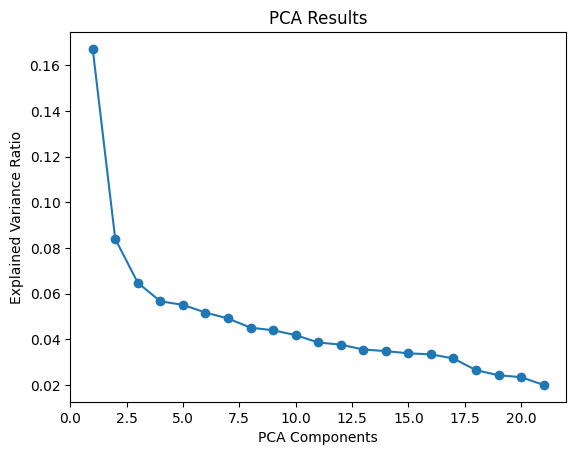

In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA().fit(scaled_data)

plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_, marker="o")
plt.xlabel("PCA Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Results")
plt.show()

In [25]:
pca.explained_variance_ratio_

array([0.16713006, 0.08396704, 0.06480288, 0.05667649, 0.05512874,
       0.05176754, 0.04916833, 0.04515407, 0.04399236, 0.04190459,
       0.03864939, 0.03771927, 0.03557995, 0.03488982, 0.03391184,
       0.03346775, 0.03166342, 0.0265529 , 0.02430867, 0.02348267,
       0.02008222])

In [26]:
# Find number of components that explain at least 85% of variance
cumulative_variance = pca.explained_variance_ratio_.cumsum()
n_components = (cumulative_variance < 0.8).sum() + 1
print(f"Number of components to explain at least 80% variance: {n_components}")

Number of components to explain at least 80% variance: 14


In [27]:
pca = PCA(n_components=n_components).fit(scaled_data)
pca_data = pca.transform(scaled_data)
print(pca_data)

[[ 4.77569195 -0.43214148  0.3356638  ...  1.07069858  0.02771312
  -0.9365576 ]
 [ 0.57292634 -5.45915935 -1.55664967 ...  0.42521384  0.4095685
   1.99007186]
 [ 4.94131986 -1.79586563  2.02481371 ... -0.59093257 -1.31928458
   1.22113362]
 ...
 [-1.30555165 -1.71669629 -0.15111092 ... -1.01693462  0.00761598
   0.42516302]
 [ 0.46393464 -0.12676433 -0.14465724 ... -0.85688877 -0.6619505
  -0.30037722]
 [ 0.78648932  1.5785753  -0.31414497 ... -1.66225812  1.62052365
   0.01119061]]


### PCA Heatmap e Matrice di Covarianza

#### Descrizione
È stata analizzata la relazione tra i componenti principali (PCA) e le feature originali attraverso una heatmap, identificando quali feature originali hanno contribuito maggiormente a ciascun componente principale. Per ogni feature, sono mostrati i pesi su ciascuna componente PCA: a partire da una tonalità molto scura, i colori rappresentano in maniera decrescente l'entità del contributo in una specifica componente principale. Viene così rivelata la distribuzione delle feature nel sottospazio della PCA.

####  Matrice di Covarianza
A giustificazione di quanto ottenuto nella heatmap, la matrice di covarianza mostra che, nella quasi totalità dei casi, le feature sono debolmente correlate fra loro. Ciò suggerisce che la maggior parte delle feature contengono informazioni potenzialmente rilevanti per la predizioni, e quindi da prendere come componente principale nella PCA.

#### Conclusioni
Dai grafici si evince che:
- Heatmap: **non esiste una singola feature dominante** su tutti i componenti principali.
- Matrice di Covarianza: le feature sono tra loro **debolmente correlate**.
Questo risultati giustificano la necessità di utilizzare **molteplici componenti PCA** (14 su 21) per catturare l'80% della varianza totale. La bassa correlazione tra le feature osservata nella matrice di covarianza si riflette nel fatto che ogni componente PCA raccoglie informazioni da diverse feature, piuttosto che concentrarsi su poche di esse. Questo rende la PCA poco utile nel contesto attuale.

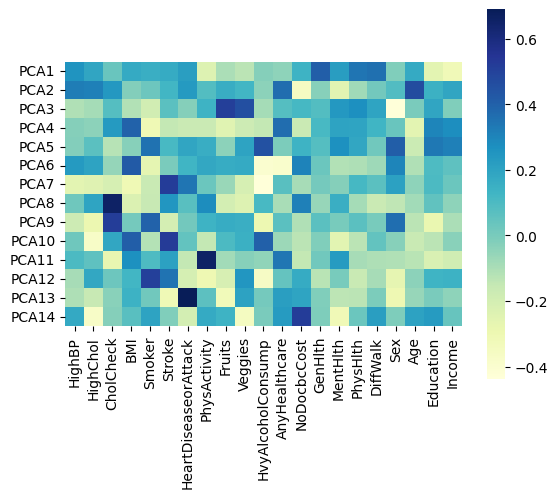

In [28]:
import seaborn as sns

ax = sns.heatmap(
    pca.components_,
    cmap="YlGnBu",
    yticklabels=["PCA" + str(x) for x in range(1, pca.n_components_ + 1)],
    xticklabels=list(numeric_features),
    cbar_kws={"orientation": "vertical"},
)
ax.set_aspect("equal")

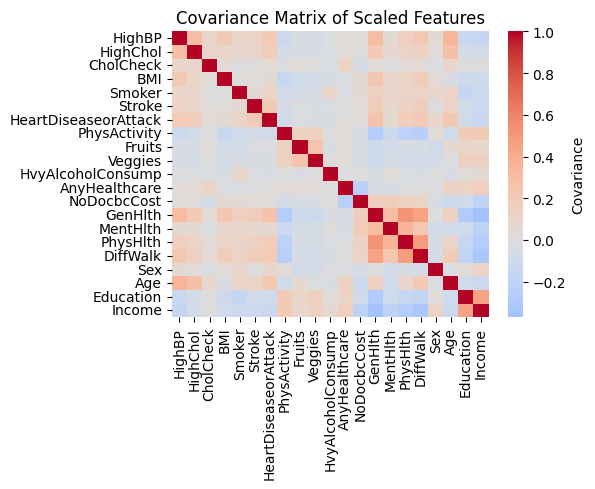

Covariance matrix shape: (21, 21)


In [29]:
# Calculate covariance matrix
cov_matrix = np.cov(scaled_data.T)

# Display covariance matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cov_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    xticklabels=numeric_features,
    yticklabels=numeric_features,
    cbar_kws={"label": "Covariance"},
)
plt.title("Covariance Matrix of Scaled Features")
plt.tight_layout()
plt.show()

print(f"Covariance matrix shape: {cov_matrix.shape}")

### Data Splitting

In [30]:
# 1. Data Preparation
X_pca = pca_data
y = df["Diabetes_binary"].values

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.3, random_state=42
)

print(f"Dimensioni Training Set: {X_train_pca.shape}")

Dimensioni Training Set: (177576, 14)


Dati gli scarsi risultati ottenuti dalla PCA, il lavoro seguente si articola su un confronto con/senza PCA

# Neural Network

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.utils import class_weight
import tensorflow as tf

In [31]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc


def evaluate_and_plot(model, X_test, y_test, history, threshold=0.5, title_suffix=""):
    # Predizioni e binarizzazione
    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > threshold).astype("int32")

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.show()

    # Report di classificazione
    print("Report di Classificazione:")
    print(classification_report(y_test, y_pred))

    # Calcolo ROC-AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    # Curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"
    )
    plt.plot(
        [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier"
    )
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    title = "Curva ROC" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    print(f"\nAUC Score: {roc_auc:.4f}")

    # Curve di Loss e Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get("loss", []), label="Train Loss")
    plt.plot(history.history.get("val_loss", []), label="Val Loss")
    plt.title("Model Loss" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history.get("accuracy", []), label="Train Accuracy")
    plt.plot(history.history.get("val_accuracy", []), label="Val Accuracy")
    plt.title("Model Accuracy" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()
    plt.show()

## No PCA

### Original Features

Architettura della rete neurale:
1) **Input:** tutte le 21 features originali standardizzate
2) **Layer Nascosti:** profondità moderata decrescente (**128 -> 64 -> 32**) come compromesso tra prestazioni e complessità. Come funzione di attivazione viene utilizzata la **ReLU** per ...
3) **Dropout (0.3):** viene ridotto l'overfitting, evitando che la rete dipenda da pattern troppo specifici come nel caso attuale di oun dataset molto sbilanciato verso la classe positiva
4) **Layer Output:** composto da un solo neurone con funzione di attivazione **Sigmoid** per produrre una distribuzione di probabilità tra 0 e 1 per la classe positiva
5) **Funzione di Loss e ottimizzazione:** viene utilizzata **Binary Cross-Entropy** in quanto si sta lavorando su feature binarie standardizzate; **Adam** consente di avere un'apprendimento più "intelligente" grazie al learning-rate adattivo
5) **Epoche (150) e Batch (256):** bilancio tra stabilità dell'ottimizzazione e tempo di training.

In [ ]:
# 3. Creazione del Modello
model = Sequential()

# Strati Nascosti
model.add(Dense(128, input_shape=(FEATURES_NUMBER,), activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model.add(Dense(1, activation="sigmoid"))

# 4. Compilazione
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

# 5. Addestramento
history = model.fit(
    X_train, y_train, epochs=150, batch_size=256, verbose=1, validation_split=0.1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8604 - loss: 0.3362 - val_accuracy: 0.8655 - val_loss: 0.3181
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8627 - loss: 0.3229 - val_accuracy: 0.8651 - val_loss: 0.3194
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8638 - loss: 0.3207 - val_accuracy: 0.8661 - val_loss: 0.3172
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8642 - loss: 0.3190 - val_accuracy: 0.8657 - val_loss: 0.3165
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8640 - loss: 0.3181 - val_accuracy: 0.8643 - val_loss: 0.3160
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8641 - loss: 0.3173 - val_accuracy: 0.8669 - val_loss: 0.3159
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8650 - loss: 0.3167 - val_accuracy: 0.8661 - val_loss: 0.3163
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8646 - loss: 0.3167 - val_accu

In [ ]:
# 6. Valutazione
evaluate_and_plot(
    model, X_test, y_test, history, title_suffix="Neural Network - No PCA"
)

InvalidArgumentError: Graph execution error:

Detected at node sequential_3_1/dense_9_1/Relu defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\ipykernel\kernelapp.py", line 758, in start

  File "C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\tornado\platform\asyncio.py", line 211, in start

  File "c:\Python313\Lib\asyncio\base_events.py", line 678, in run_forever

  File "c:\Python313\Lib\asyncio\base_events.py", line 2033, in _run_once

  File "c:\Python313\Lib\asyncio\events.py", line 89, in _run

  File "C:\Users\Daniel\AppData\Roaming\Python\Python313\sit

note:
- fortemente dipendente dalla classe negativa (alto numero di veri e falsi negativi)
- ROC: valore >0.8 indica una buona separabilità delle classi: il modello distingue discretamente, seppur in maniera errata, gli esempi positivi da quelli negativi

- Training: validation loss non diverge in maniera marcata. Vi è un inizio di overfitting che però è controllato dal dropout

- come base di partenza il modello è stabile, ma in un contesto clinico come questo bisogna assolutamente ridurre il numero di falsi negativi

### Undersampling

L'architettura della rete presenta un numero di neuroni dimezzato per ogni layer rispetto a quella precedente, poichè si sta lavorando su una porzione del dataset di partenza

In [ ]:
# 3. Creazione del Modello
model_pca_under_without_noise = Sequential()
model_pca_under_without_noise.add(Dense(64, input_shape=(FEATURES_NUMBER,), activation="relu"))
model_pca_under_without_noise.add(Dropout(0.5))

model_pca_under_without_noise.add(Dense(32, activation="relu"))
model_pca_under_without_noise.add(Dropout(0.3))

model_pca_under_without_noise.add(Dense(16, activation="relu"))
model_pca_under_without_noise.add(Dropout(0.3))

model_pca_under_without_noise.add(Dense(1, activation="sigmoid"))


# 4. Compilazione
model_pca_under_without_noise.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# 5. Addestramento
history_pca_under = model_pca_under_without_noise.fit(
    X_train_bal,
    y_train_bal,
    epochs=100,
    batch_size=128,
    verbose=1,
    validation_split=0.1,
)

Epoch 1/100


C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_45" is incompatible with the layer: expected axis -1 of input shape to have value 21, but received input with shape (None, 13)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 13), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

663/663 ━━━━━━━━━━━━━━━━━━━━ 1s 797us/step


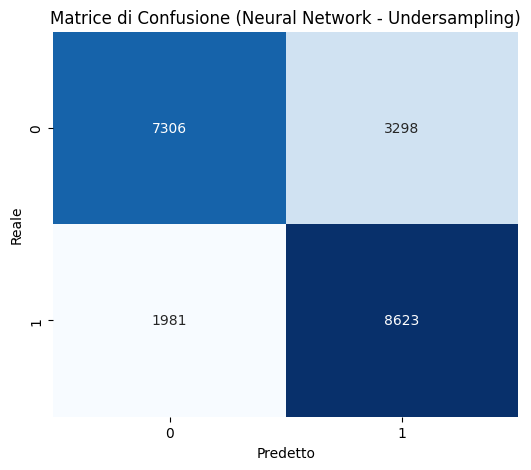

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.79      0.69      0.73     10604
           1       0.72      0.81      0.77     10604

    accuracy                           0.75     21208
   macro avg       0.76      0.75      0.75     21208
weighted avg       0.76      0.75      0.75     21208



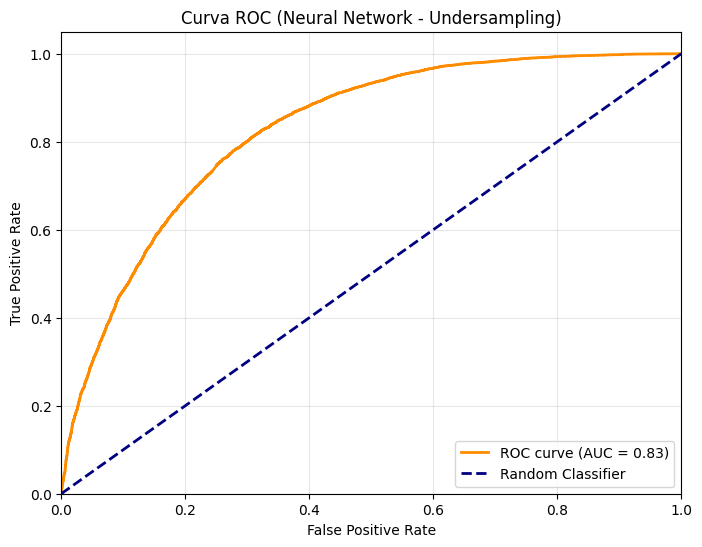


AUC Score: 0.8264


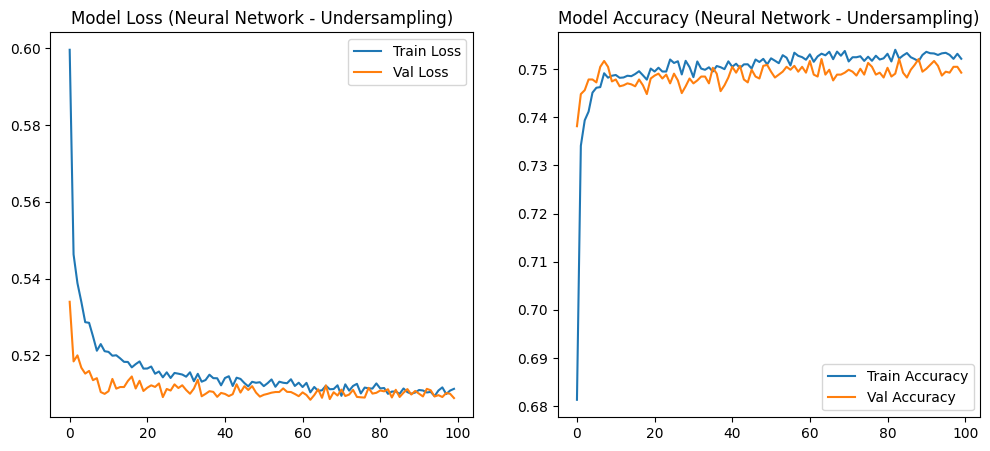

In [ ]:
# 6. Valutazione
evaluate_and_plot(
    model_pca_under_without_noise,
    X_test_bal,
    y_test_bal,
    history_pca_under,
    title_suffix="Neural Network - Undersampling",
)

Trattando le classi alla pari, l'approccio con undersampling + class balancing ha reso il modello più stabile (le precision e recall medie sono notevolmente aumentate) e più tendente a classificare come positive le istanze (la percentuale di falsi negativi è molto minore a quella dei falsi positivi). La curva ROC è pressoché identica, segno che la capacità di classificazione non è cambiata. Train e Loss seguono lo stesso andamento, a prova del fatto che il modello è ora meno soggetto a overfitting grazie al bilanciamento delle classi

### Class Weights

A partire dal dataset originale (senza undersampling), sono applicati pesi bilanciati per rendere più costosi gli errori sulla classe maggioritaria (positiva) e limitare la tendenza del modello a convergere nella direzione della classe dominante durante il training. L'architettura della rete ritorna alla sua composizione di partenza per lavorare sul dataset originale

In [ ]:
# 2. Calcolo dei Class Weights
class_weights_vals = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Pesi delle classi: {class_weights}")


# 3. Creazione del modello
model_no_pca_weighted = Sequential()

# Strati Nascosti
model_no_pca_weighted.add(Dense(128, input_shape=(FEATURES_NUMBER,), activation="relu"))
model_no_pca_weighted.add(Dropout(0.3))

model_no_pca_weighted.add(Dense(64, activation="relu"))
model_no_pca_weighted.add(Dropout(0.3))

model_no_pca_weighted.add(Dense(32, activation="relu"))
model_no_pca_weighted.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model_no_pca_weighted.add(Dense(1, activation="sigmoid"))


# 4. Compilazione
model_no_pca_weighted.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# 5. Addestramento con Class Weights
history_no_pca_weighted = model_no_pca_weighted.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
    class_weight=class_weights,
)

Pesi delle classi: {0: np.float64(0.5813434252826902), 1: np.float64(3.5733891415462633)}
Epoch 1/150


C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6953 - loss: 0.5349 - val_accuracy: 0.6984 - val_loss: 0.5157
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7056 - loss: 0.5179 - val_accuracy: 0.7091 - val_loss: 0.5090
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7092 - loss: 0.5137 - val_accuracy: 0.7129 - val_loss: 0.5053
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7132 - loss: 0.5119 - val_accuracy: 0.7162 - val_loss: 0.5059
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7132 - loss: 0.5101 - val_accuracy: 0.7193 - val_loss: 0.5053
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7189 - loss: 0.5088 - val_accuracy: 0.7133 - val_loss: 0.5216
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7206 - loss: 0.5091 - val_accuracy: 0.7129 - val_loss: 0.5147
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7210 - loss: 0.5081 - val_accuracy: 0.7244

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 753us/step


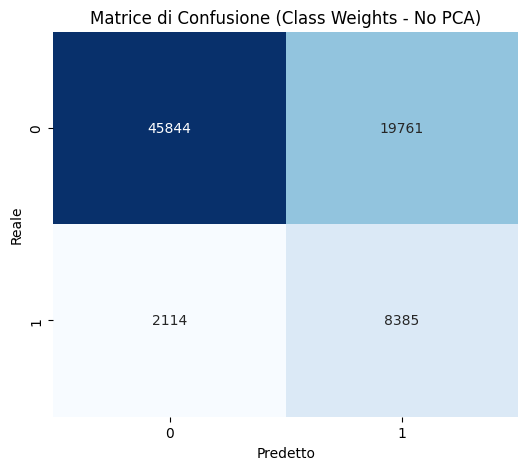

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     65605
           1       0.30      0.80      0.43     10499

    accuracy                           0.71     76104
   macro avg       0.63      0.75      0.62     76104
weighted avg       0.87      0.71      0.76     76104



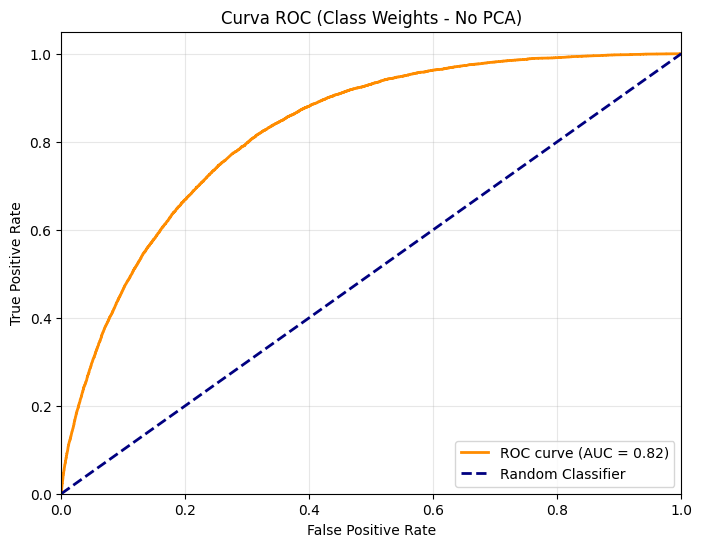


AUC Score: 0.8249


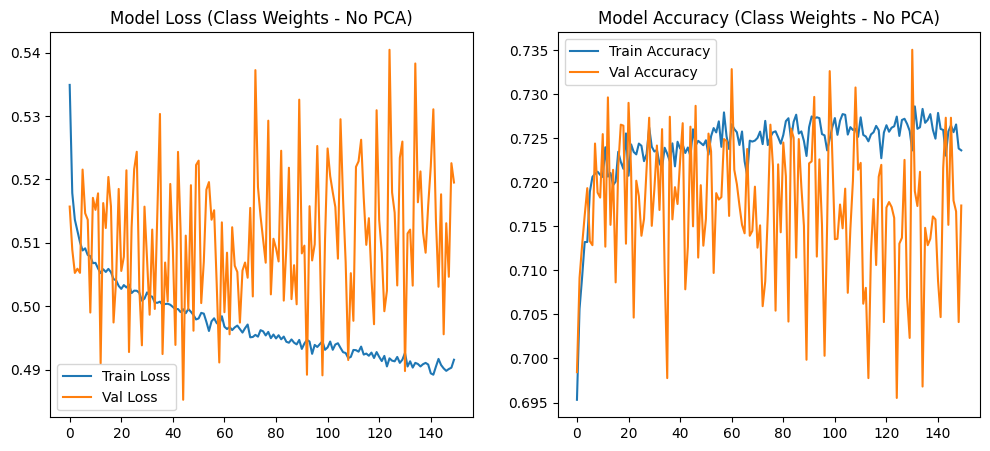

In [ ]:
# 6. Valutazione
evaluate_and_plot(
    model_no_pca_weighted,
    X_test,
    y_test,
    history_no_pca_weighted,
    title_suffix="Class Weights - No PCA",
)

L'approccio con Class Weights ottiene un recall dei positivi ancora a 0.78, quindi paragonabile all'undersampling, ma con una precisione più bassa (0.31) e curve di validazione più rumorose che tendono a divergere leggermente dal train. Questo rumore suggerisce che il modello oscilla nel trovare l'equilibrio tra i pesi, ma comunque riesce a limitare la tendenza del modello originale a sbilanciarsi verso la classe maggioritaria, come nel caso dell'undersampling. Infatti, guardando la matrice di confusione si nota una grande somiglianza con l'approccio `undersampling + class balancing`: meno FN e più FP rispetto al modello base, ma senza la perdita di informazione dovuta al undersampling stesso.

### Focal Loss
Va leggermente meglio (non so quanto, da analizzare...) però ha un maggior onere computazionale.
A livello di tempi Class Weights è molto più veloce.

In [ ]:
# Definizione corretta della Focal Loss per classificazione binaria
def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss per classificazione binaria sbilanciata.

    Parameters:
    - gamma: focusing parameter (default=2.0). Maggiore è gamma, più il modello si concentra sugli esempi difficili
    - alpha: peso per la classe positiva (default=0.25). Per dati sbilanciati, usa alpha ≈ frequenza classe negativa
    """

    def focal_loss_fixed(y_true, y_pred):
        # Converti tutto a float32 per evitare problemi di tipo
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        # Binary Cross Entropy
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)

        # Focal Loss modulation
        # Per gli esempi della classe 1 (y_true=1): p_t = y_pred
        # Per gli esempi della classe 0 (y_true=0): p_t = 1 - y_pred
        p_t = tf.where(tf.equal(y_true, 1.0), y_pred, 1 - y_pred)

        # Alpha balancing (converti alpha a float32)
        alpha_f32 = tf.constant(alpha, dtype=tf.float32)
        alpha_t = tf.where(tf.equal(y_true, 1.0), alpha_f32, 1 - alpha_f32)

        # Focal term: (1 - p_t)^gamma (converti gamma a float32)
        gamma_f32 = tf.constant(gamma, dtype=tf.float32)
        focal_weight = tf.pow(1.0 - p_t, gamma_f32)

        # Focal Loss finale
        focal_loss = alpha_t * focal_weight * bce

        return tf.reduce_mean(focal_loss)

    return focal_loss_fixed

In [ ]:
# Calcola alpha ottimale basato sulla distribuzione delle classi
class_freq_np = np.bincount(y_train.astype(int))
alpha_optimal_np = float(class_freq_np[0] / (class_freq_np[0] + class_freq_np[1]))
print(f"Alpha ottimale calcolato: {alpha_optimal_np:.3f}")

# 2. Creazione del Modello
model_no_pca_focal = Sequential()

# Strati Nascosti
model_no_pca_focal.add(Dense(128, input_shape=(FEATURES_NUMBER,), activation="relu"))
model_no_pca_focal.add(Dropout(0.3))

model_no_pca_focal.add(Dense(64, activation="relu"))
model_no_pca_focal.add(Dropout(0.3))

model_no_pca_focal.add(Dense(32, activation="relu"))
model_no_pca_focal.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model_no_pca_focal.add(Dense(1, activation="sigmoid"))

# 3. Compilazione con Focal Loss
model_no_pca_focal.compile(
    loss=focal_loss(gamma=2.0, alpha=alpha_optimal_np),
    optimizer="adam",
    metrics=["accuracy"],
)

# 4. Addestramento
history_no_pca_focal = model_no_pca_focal.fit(
    X_train, y_train, epochs=150, batch_size=256, verbose=1, validation_split=0.1
)

Alpha ottimale calcolato: 0.860
Epoch 1/150


C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6893 - loss: 0.0338 - val_accuracy: 0.6715 - val_loss: 0.0321
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6973 - loss: 0.0322 - val_accuracy: 0.7037 - val_loss: 0.0319
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7028 - loss: 0.0319 - val_accuracy: 0.7016 - val_loss: 0.0317
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7086 - loss: 0.0317 - val_accuracy: 0.7118 - val_loss: 0.0316
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7133 - loss: 0.0316 - val_accuracy: 0.7187 - val_loss: 0.0316
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7171 - loss: 0.0316 - val_accuracy: 0.7015 - val_loss: 0.0315
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7161 - loss: 0.0315 - val_accuracy: 0.7114 - val_loss: 0.0315
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7167 - loss: 0.0315 - val_accuracy: 0.7122

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


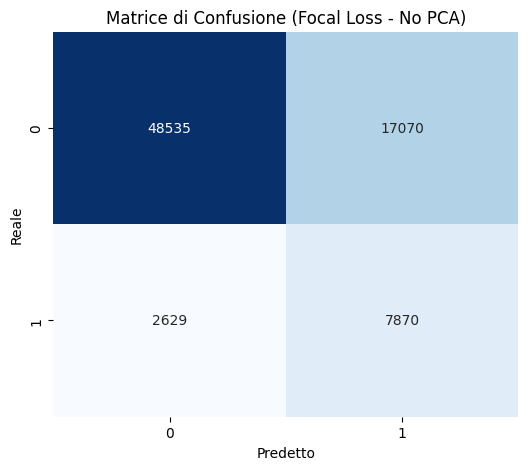

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.95      0.74      0.83     65605
           1       0.32      0.75      0.44     10499

    accuracy                           0.74     76104
   macro avg       0.63      0.74      0.64     76104
weighted avg       0.86      0.74      0.78     76104



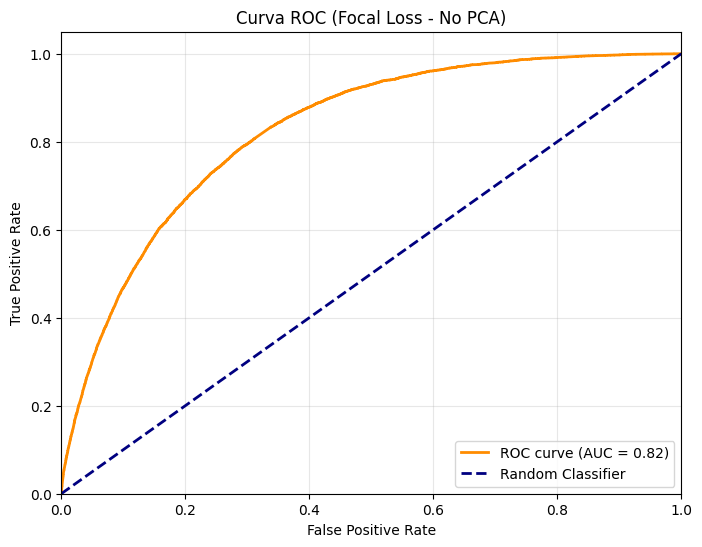


AUC Score: 0.8244


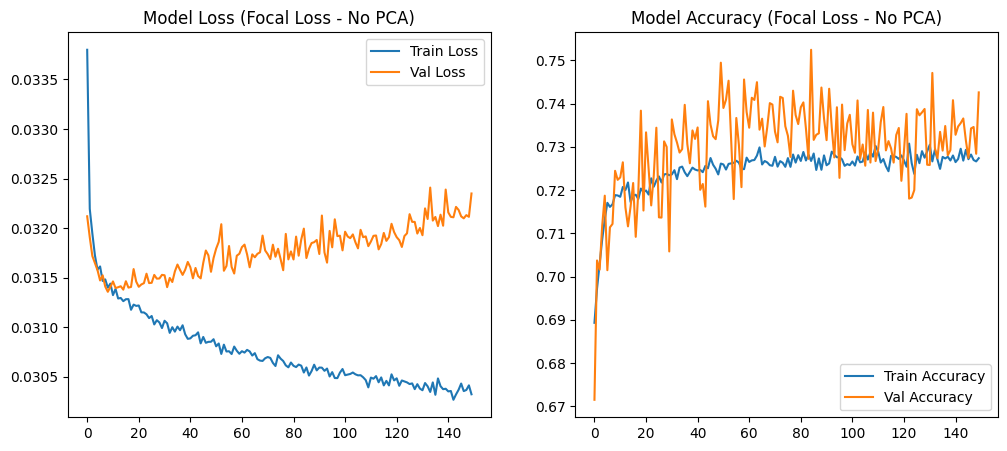

In [ ]:
# 5. Valutazione
evaluate_and_plot(
    model_no_pca_focal,
    X_test,
    y_test,
    history_no_pca_focal,
    title_suffix="Focal Loss - No PCA",
)

## PCA

### Class Weights

Considerando le componenti principali estratte dalla PCA, viene adottato il class weight sul dataset originale

In [ ]:
# 2. Calcolo dei Class Weights
class_weights_vals = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train_pca), y=y_train_pca
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Pesi delle classi: {class_weights}")

# 3. Creazione del Modello
model_pca_weighted = Sequential()
model_pca_weighted.add(Dense(32, input_shape=(n_components,), activation="relu"))
model_pca_weighted.add(Dropout(0.3))

model_pca_weighted.add(Dense(16, activation="relu"))
model_pca_weighted.add(Dropout(0.3))

model_pca_weighted.add(Dense(8, activation="relu"))
model_pca_weighted.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model_pca_weighted.add(Dense(1, activation="sigmoid"))

# 4. Compilazione
model_pca_weighted.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# 5. Addestramento con Class Weights
history_pca_weighted = model_pca_weighted.fit(
    X_train_pca,
    y_train_pca,
    epochs=150,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
    class_weight=class_weights,
)

Pesi delle classi: {0: np.float64(0.5813434252826902), 1: np.float64(3.5733891415462633)}
Epoch 1/150


C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6530 - loss: 0.6104 - val_accuracy: 0.6903 - val_loss: 0.5182
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7035 - loss: 0.5661 - val_accuracy: 0.7062 - val_loss: 0.5084
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7048 - loss: 0.5564 - val_accuracy: 0.7140 - val_loss: 0.4979
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7072 - loss: 0.5511 - val_accuracy: 0.7101 - val_loss: 0.5028
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7053 - loss: 0.5489 - val_accuracy: 0.6941 - val_loss: 0.5195
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7038 - loss: 0.5465 - val_accuracy: 0.7016 - val_loss: 0.5054
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7029 - loss: 0.5433 - val_accuracy: 0.6960 - val_loss: 0.5138
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7069 - loss: 0.5437 - val_accuracy: 0.7035

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step


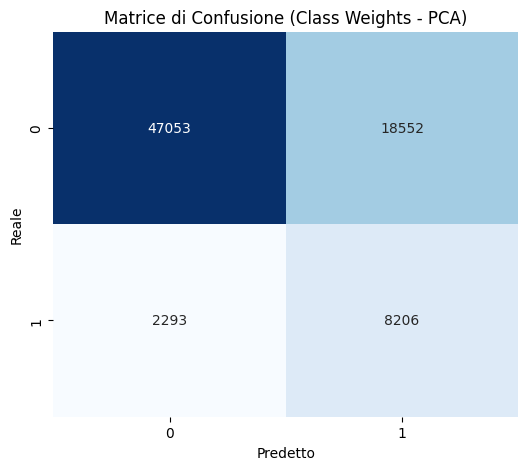

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.95      0.72      0.82     65605
           1       0.31      0.78      0.44     10499

    accuracy                           0.73     76104
   macro avg       0.63      0.75      0.63     76104
weighted avg       0.86      0.73      0.77     76104



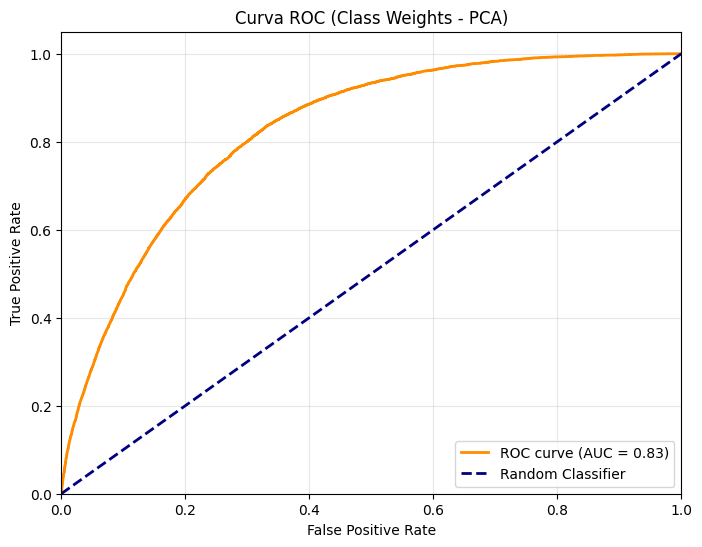


AUC Score: 0.8250


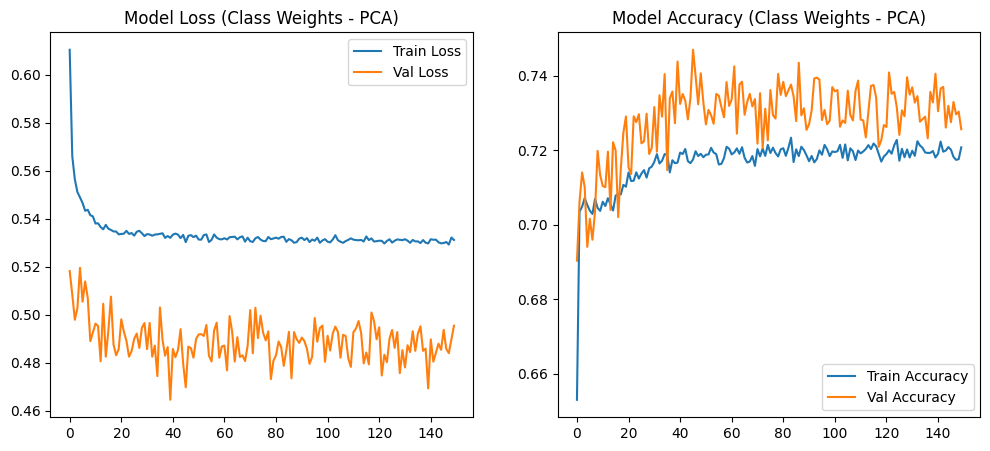

In [ ]:
# 6. Valutazione
evaluate_and_plot(
    model_pca_weighted,
    X_test_pca,
    y_test_pca,
    history_pca_weighted,
    title_suffix="Class Weights - PCA",
)

Rispetto al suo equivalente senza PCA, il modello sacrifica il numero dei FP e l'accuratezza generale in favore della massimizzazione della sensabilità sulla classe negativa.
NOTE: modelli utili in entrambi i contesti d'uso:
- attenzione nel "non-perdersi" individui positivi: preferire PCA + class weight
- attenzione nel ridurre i "falsi allarmi": preferire no PCA + class weight

### Focal Loss
Direi di togliere questa parte, non porta miglioramenti significativi.

In [ ]:
# Calcola alpha ottimale basato sulla distribuzione delle classi
# alpha ≈ freq(classe 0) per dare più peso alla classe minoritaria (1)
class_freq = np.bincount(y_train_pca.astype(int))
alpha_optimal = float(class_freq[0] / (class_freq[0] + class_freq[1]))
print(f"Alpha ottimale calcolato: {alpha_optimal:.3f}")

# 2. Creazione del Modello
model_pca_focal = Sequential()

model_pca_focal.add(Dense(32, input_shape=(n_components,), activation="relu"))
model_pca_focal.add(Dropout(0.3))

model_pca_focal.add(Dense(16, activation="relu"))
model_pca_focal.add(Dropout(0.3))

model_pca_focal.add(Dense(8, activation="relu"))
model_pca_focal.add(Dropout(0.3))

model_pca_focal.add(Dense(1, activation="sigmoid"))

# 3. Compilazione con Focal Loss
# Usa gamma=2.0 e alpha calcolato automaticamente
model_pca_focal.compile(
    loss=focal_loss(gamma=2.0, alpha=alpha_optimal),
    optimizer="adam",
    metrics=["accuracy"],
)

# 4. Addestramento
history_pca_focal = model_pca_focal.fit(
    X_train_pca,
    y_train_pca,
    epochs=150,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
)

Alpha ottimale calcolato: 0.860
Epoch 1/150


C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6535 - loss: 0.0375 - val_accuracy: 0.6702 - val_loss: 0.0336
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6775 - loss: 0.0346 - val_accuracy: 0.6799 - val_loss: 0.0328
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6642 - loss: 0.0338 - val_accuracy: 0.6991 - val_loss: 0.0325
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6752 - loss: 0.0337 - val_accuracy: 0.7009 - val_loss: 0.0323
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6826 - loss: 0.0334 - val_accuracy: 0.7048 - val_loss: 0.0323
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6876 - loss: 0.0334 - val_accuracy: 0.6999 - val_loss: 0.0323
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7037 - loss: 0.0332 - val_accuracy: 0.7094 - val_loss: 0.0323
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7046 - loss: 0.0330 - val_accuracy: 0.6947

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 803us/step


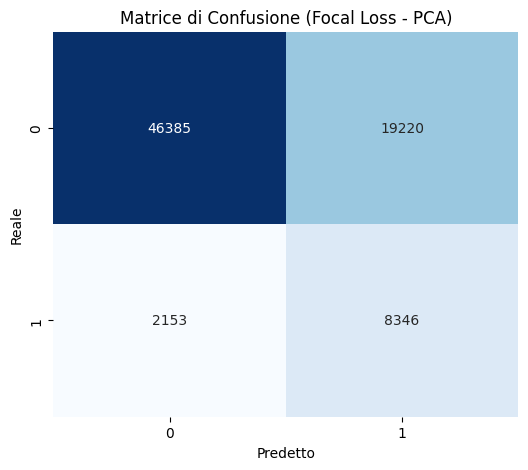

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.96      0.71      0.81     65605
           1       0.30      0.79      0.44     10499

    accuracy                           0.72     76104
   macro avg       0.63      0.75      0.63     76104
weighted avg       0.87      0.72      0.76     76104



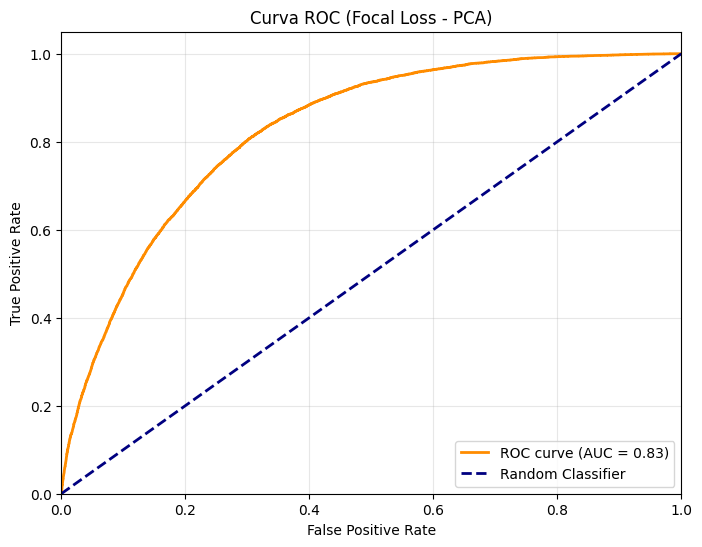


AUC Score: 0.8252


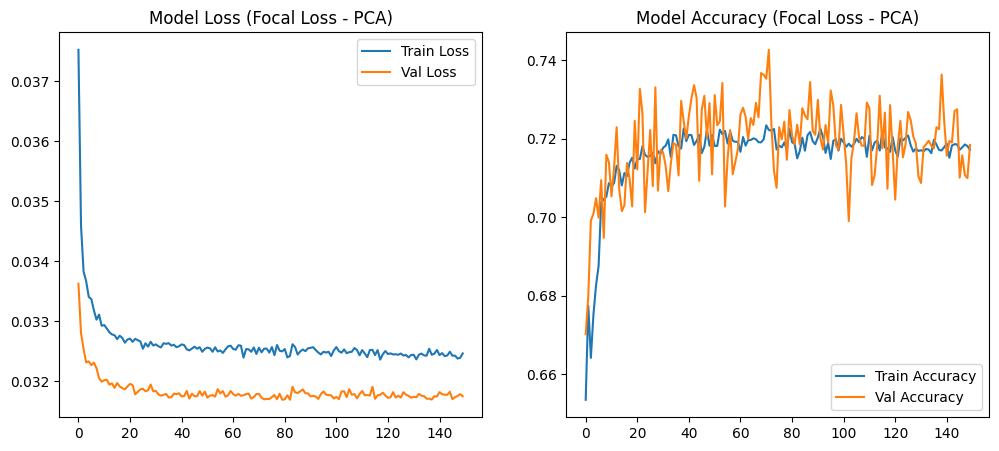

In [ ]:
# 5. Valutazione
evaluate_and_plot(
    model_pca_focal,
    X_test_pca,
    y_test_pca,
    history_pca_focal,
    title_suffix="Focal Loss - PCA",
)

## Eliminazione del rumore

In [9]:
features_without_noise = df.drop(columns=["ID", "Diabetes_binary", "Fruits", "Veggies", "AnyHealthcare", "NoDocbcCost", "Education", "Income", "CholCheck", "MentHlth"])
features_without_noise.dtypes

HighBP                  int64
HighChol                int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
HvyAlcoholConsump       int64
GenHlth                 int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
dtype: object

In [16]:
numeric_features_without_noise = features_without_noise.select_dtypes(["int64"]).columns
FEATURES_WITHOUT_NOISE_NUMBER = len(numeric_features_without_noise)

print(FEATURES_WITHOUT_NOISE_NUMBER)

13


In [17]:
scaled_data_without_noise = scaler.fit_transform(features_without_noise)
print(scaled_data)

[[ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
  -1.4744874 ]
 [-0.86678537 -0.85818163 -5.07816412 ... -0.33793279  0.96327159
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
   0.93963796]
 ...
 [-0.86678537 -0.85818163  0.19692156 ... -1.97501498 -0.05116153
  -1.95731247]
 [ 1.15368814 -0.85818163  0.19692156 ... -0.33793279 -0.05116153
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008  0.96327159
  -1.95731247]]


In [34]:
X_without_noise = scaled_data_without_noise
y = df["Diabetes_binary"].values

# Split in Train e Test
X_train_without_noise, X_test_without_noise, y_train, y_test = train_test_split(
    X_without_noise, y, test_size=0.3, random_state=42
)

### Sbilanciato

In [35]:
model = Sequential()

# Strati Nascosti
model.add(Dense(128, input_shape=(FEATURES_WITHOUT_NOISE_NUMBER,), activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model.add(Dense(1, activation="sigmoid"))

# 3. Compilazione
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

# 4. Addestramento
history = model.fit(
    X_train_without_noise, y_train, epochs=150, batch_size=256, verbose=1, validation_split=0.1
)

C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8609 - loss: 0.3376 - val_accuracy: 0.8665 - val_loss: 0.3199
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8636 - loss: 0.3240 - val_accuracy: 0.8647 - val_loss: 0.3192
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8641 - loss: 0.3215 - val_accuracy: 0.8661 - val_loss: 0.3175
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8646 - loss: 0.3204 - val_accuracy: 0.8674 - val_loss: 0.3172
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8644 - loss: 0.3196 - val_accuracy: 0.8655 - val_loss: 0.3181
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8639 - loss: 0.3201 - val_accuracy: 0.8665 - val_loss: 0.3167
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8645 - loss: 0.3185 - val_accuracy: 0.8654 - val_loss: 0.3167
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8644 - loss: 0.3187 - val_accu

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 896us/step


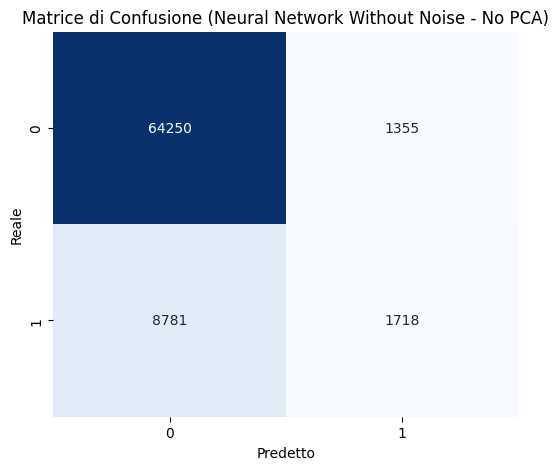

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93     65605
           1       0.56      0.16      0.25     10499

    accuracy                           0.87     76104
   macro avg       0.72      0.57      0.59     76104
weighted avg       0.84      0.87      0.83     76104



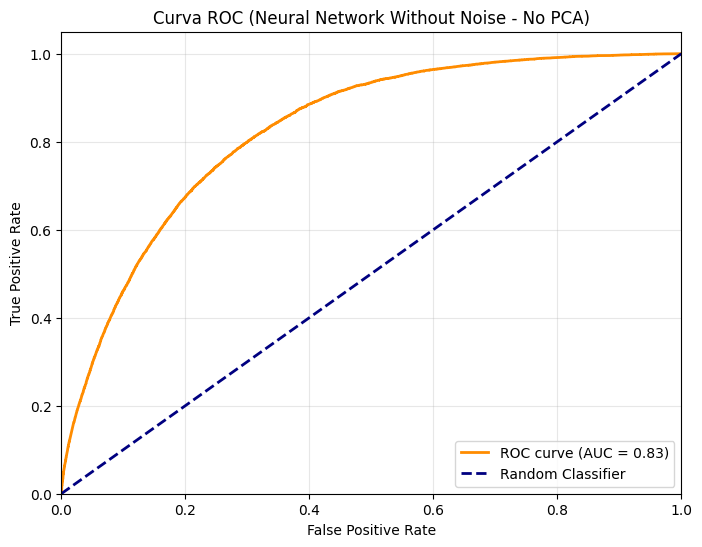


AUC Score: 0.8259


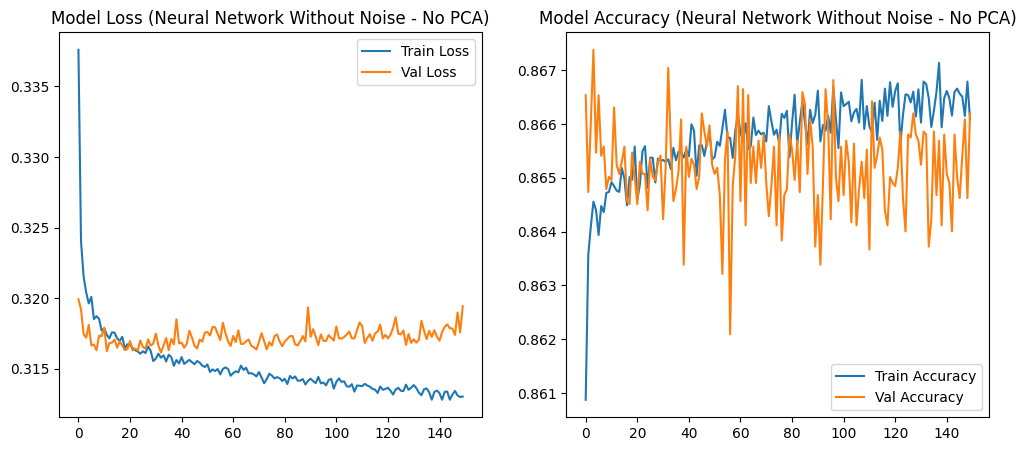

In [36]:
evaluate_and_plot(
    model, X_test_without_noise, y_test, history, title_suffix="Neural Network Without Noise - No PCA"
)

### Bilanciato

In [ ]:
X_bal, y_bal = balance_dataset(X_without_noise, y)

X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal
)

model_pca_under_without_noise = Sequential()
model_pca_under_without_noise.add(Dense(64, input_shape=(FEATURES_WITHOUT_NOISE_NUMBER,), activation="relu"))
model_pca_under_without_noise.add(Dropout(0.5))

model_pca_under_without_noise.add(Dense(32, activation="relu"))
model_pca_under_without_noise.add(Dropout(0.3))

model_pca_under_without_noise.add(Dense(16, activation="relu"))
model_pca_under_without_noise.add(Dropout(0.3))

model_pca_under_without_noise.add(Dense(1, activation="sigmoid"))

model_pca_under_without_noise.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

history_pca_under_without_noise = model_pca_under_without_noise.fit(
    X_train_bal,
    y_train_bal,
    epochs=200,
    batch_size=128,
    verbose=1,
    validation_split=0.1,
)

Epoch 1/200


C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6895 - loss: 0.5897 - val_accuracy: 0.7454 - val_loss: 0.5229
Epoch 2/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7361 - loss: 0.5425 - val_accuracy: 0.7488 - val_loss: 0.5192
Epoch 3/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7428 - loss: 0.5351 - val_accuracy: 0.7484 - val_loss: 0.5167
Epoch 4/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7440 - loss: 0.5332 - val_accuracy: 0.7509 - val_loss: 0.5146
Epoch 5/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7446 - loss: 0.5277 - val_accuracy: 0.7539 - val_loss: 0.5142
Epoch 6/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7471 - loss: 0.5275 - val_accuracy: 0.7543 - val_loss: 0.5122
Epoch 7/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7471 - loss: 0.5267 - val_accuracy: 0.7547 - val_loss: 0.5144
Epoch 8/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7477 - loss: 0.5247 - val_accuracy: 0.7541

663/663 ━━━━━━━━━━━━━━━━━━━━ 1s 809us/step


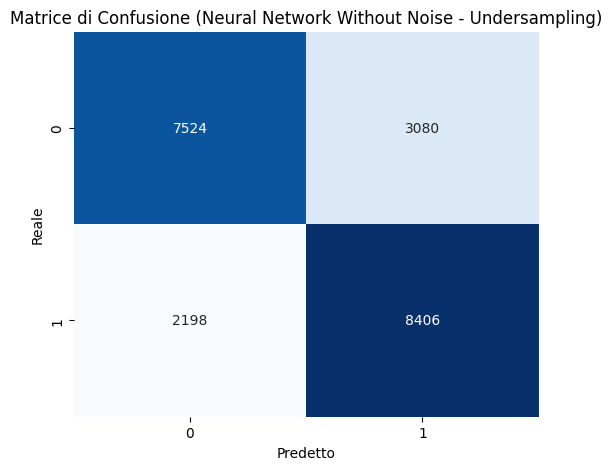

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.77      0.71      0.74     10604
           1       0.73      0.79      0.76     10604

    accuracy                           0.75     21208
   macro avg       0.75      0.75      0.75     21208
weighted avg       0.75      0.75      0.75     21208



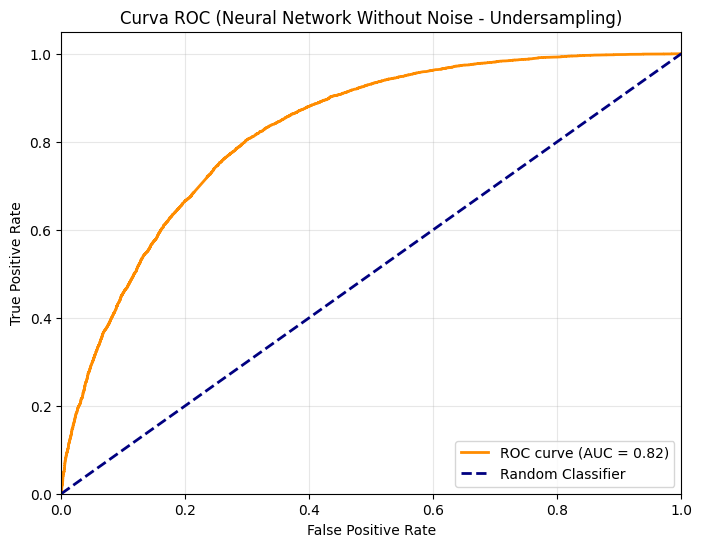


AUC Score: 0.8245


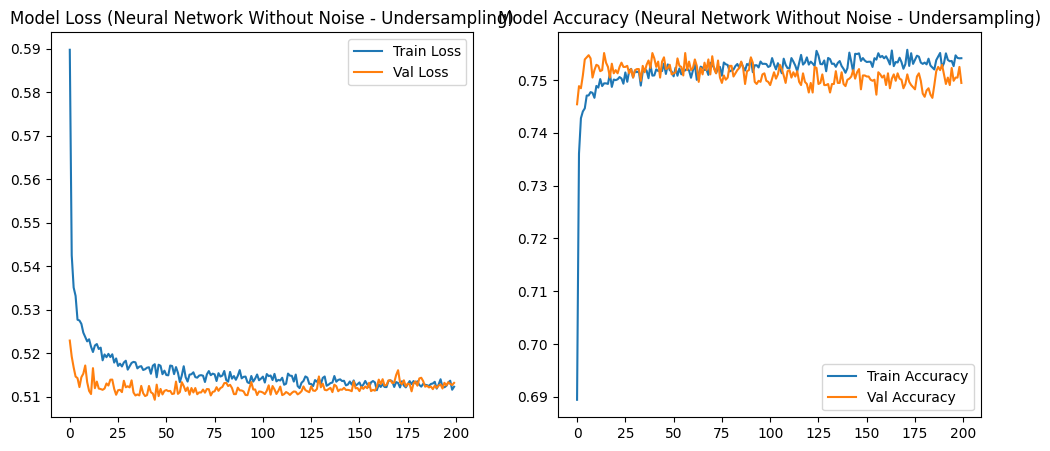

In [49]:
evaluate_and_plot(
    model_pca_under_without_noise,
    X_test_bal,
    y_test_bal,
    history_pca_under_without_noise,
    title_suffix="Neural Network Without Noise - Undersampling",
)

# Decision Tree

In [69]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.tree import plot_tree


def show_tree_metrics(tree, y_test, y_pred):
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    if hasattr(tree, "get_depth"):
        print(f"Profondità albero: {tree.get_depth()}")
        print(f"Numero di foglie: {tree.get_n_leaves()}")

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione"
    plt.title(title)
    plt.show()

    print("\n" + classification_report(y_test, y_pred))


def print_tree(tree, max_depth, title):
    plt.figure(figsize=(50, 24))
    plot_tree(
        tree,
        filled=True,
        feature_names=numeric_features,
        class_names=["0", "1"],
        fontsize=8,
        max_depth=max_depth,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

## No PCA

### No Pruning

Introdotto class_weight='balanced' e ccp_alpha=0.001

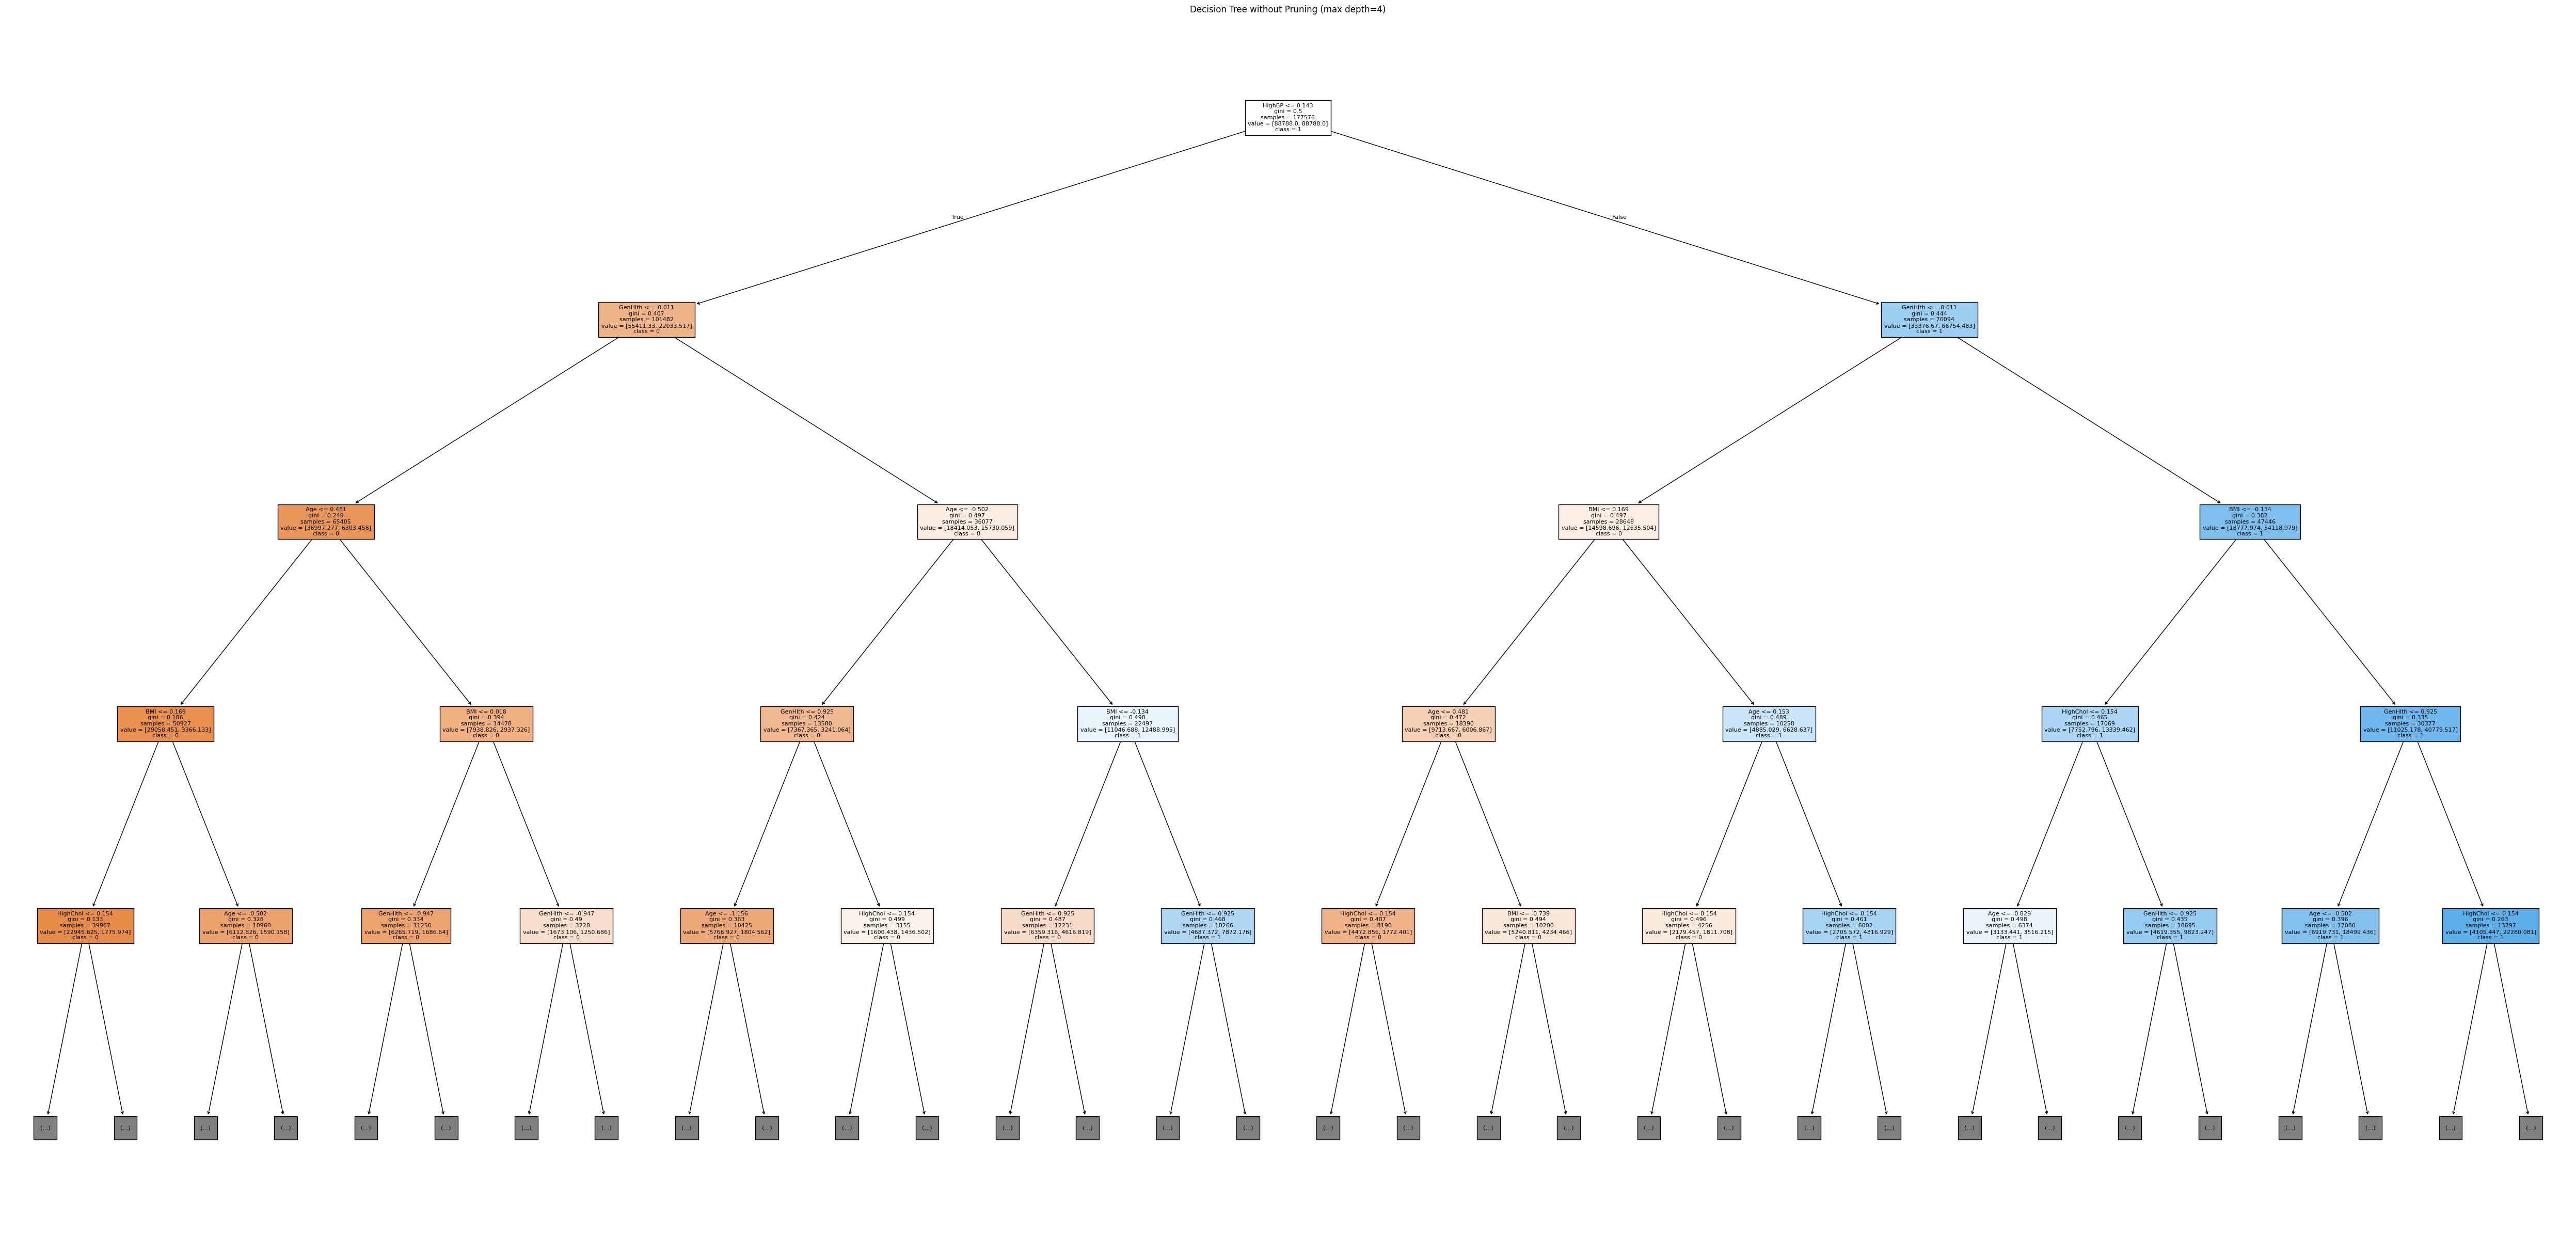

Accuracy: 0.7979
Profondità albero: 41
Numero di foglie: 38420


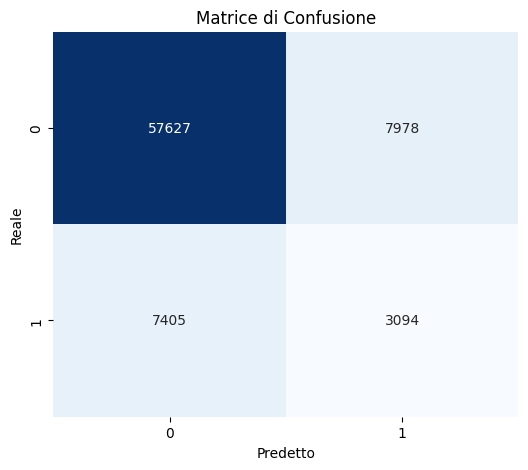


              precision    recall  f1-score   support

           0       0.89      0.88      0.88     65605
           1       0.28      0.29      0.29     10499

    accuracy                           0.80     76104
   macro avg       0.58      0.59      0.58     76104
weighted avg       0.80      0.80      0.80     76104



In [70]:
from sklearn.tree import DecisionTreeClassifier

dt_no_pruning = DecisionTreeClassifier(
    random_state=42, class_weight="balanced"
)
dt_no_pruning.fit(X_train, y_train)

y_pred_no_prune = dt_no_pruning.predict(X_test)

print_tree(dt_no_pruning, 4, "Decision Tree without Pruning (max depth=4)")
show_tree_metrics(dt_no_pruning, y_test, y_pred_no_prune)

#### Class Balancing

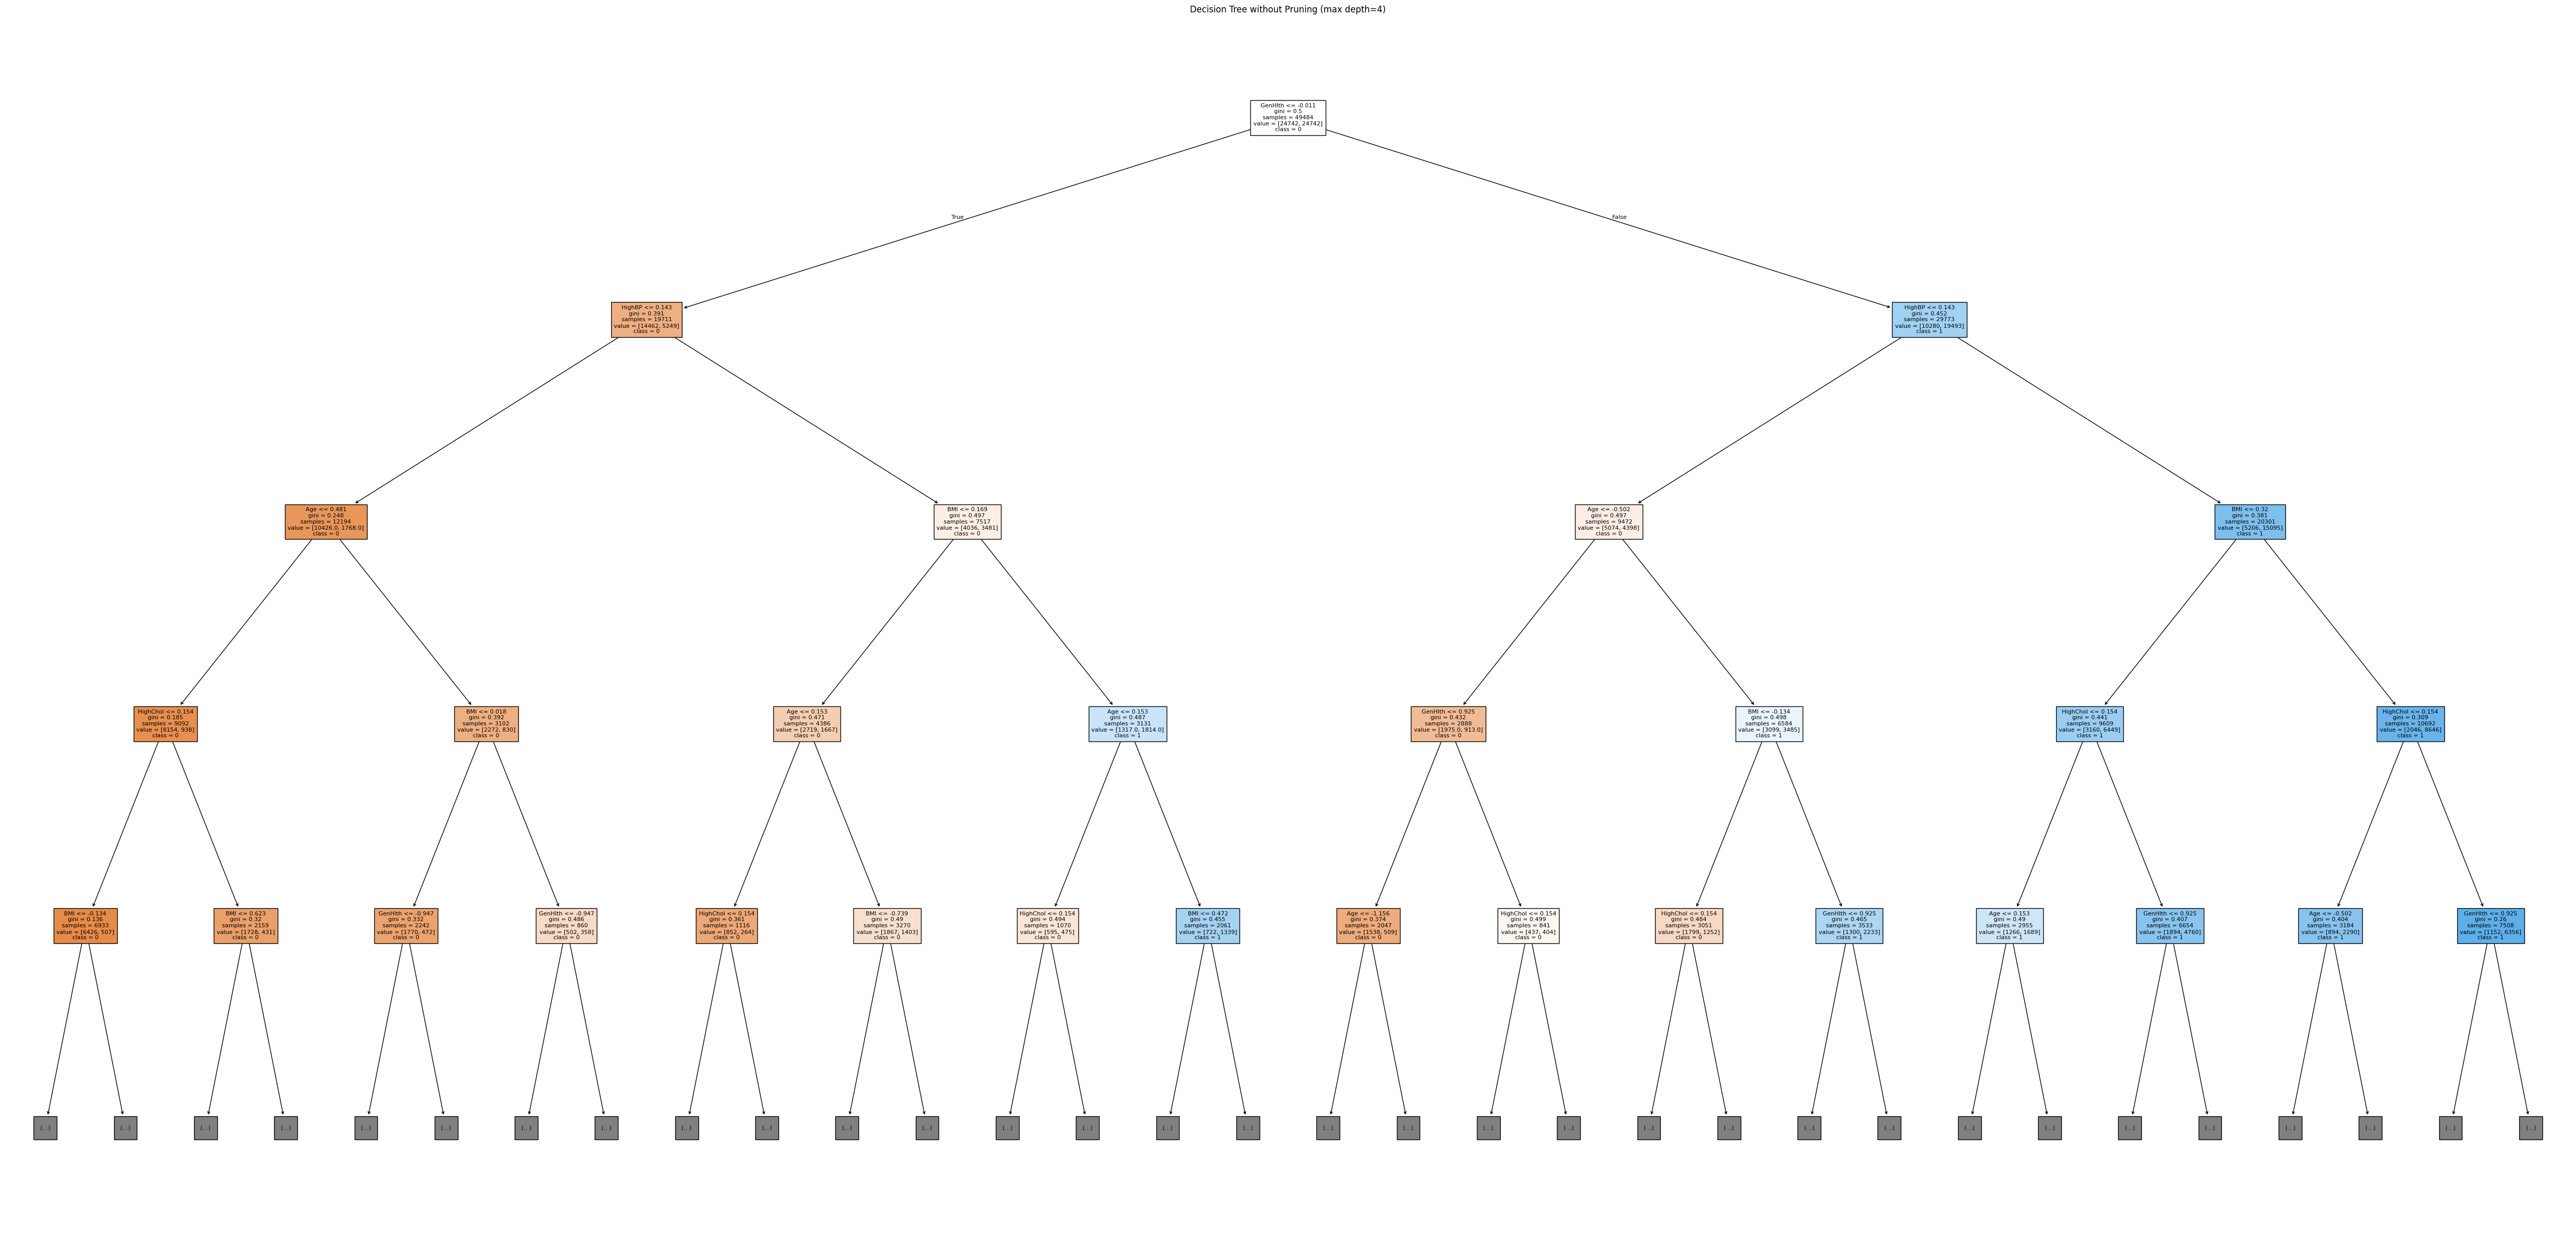

Accuracy: 0.6571
Profondità albero: 37
Numero di foglie: 14121


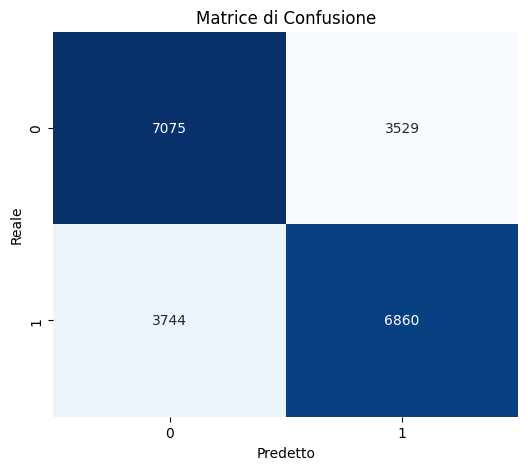


              precision    recall  f1-score   support

           0       0.65      0.67      0.66     10604
           1       0.66      0.65      0.65     10604

    accuracy                           0.66     21208
   macro avg       0.66      0.66      0.66     21208
weighted avg       0.66      0.66      0.66     21208



In [71]:
dt_no_pruning_bal = DecisionTreeClassifier(random_state=42)
dt_no_pruning_bal.fit(X_train_bal, y_train_bal)

y_pred_no_prune_bal = dt_no_pruning_bal.predict(X_test_bal)

print_tree(dt_no_pruning_bal, 4, "Decision Tree without Pruning (max depth=4)")
show_tree_metrics(dt_no_pruning_bal, y_test_bal, y_pred_no_prune_bal)

### With Pruning

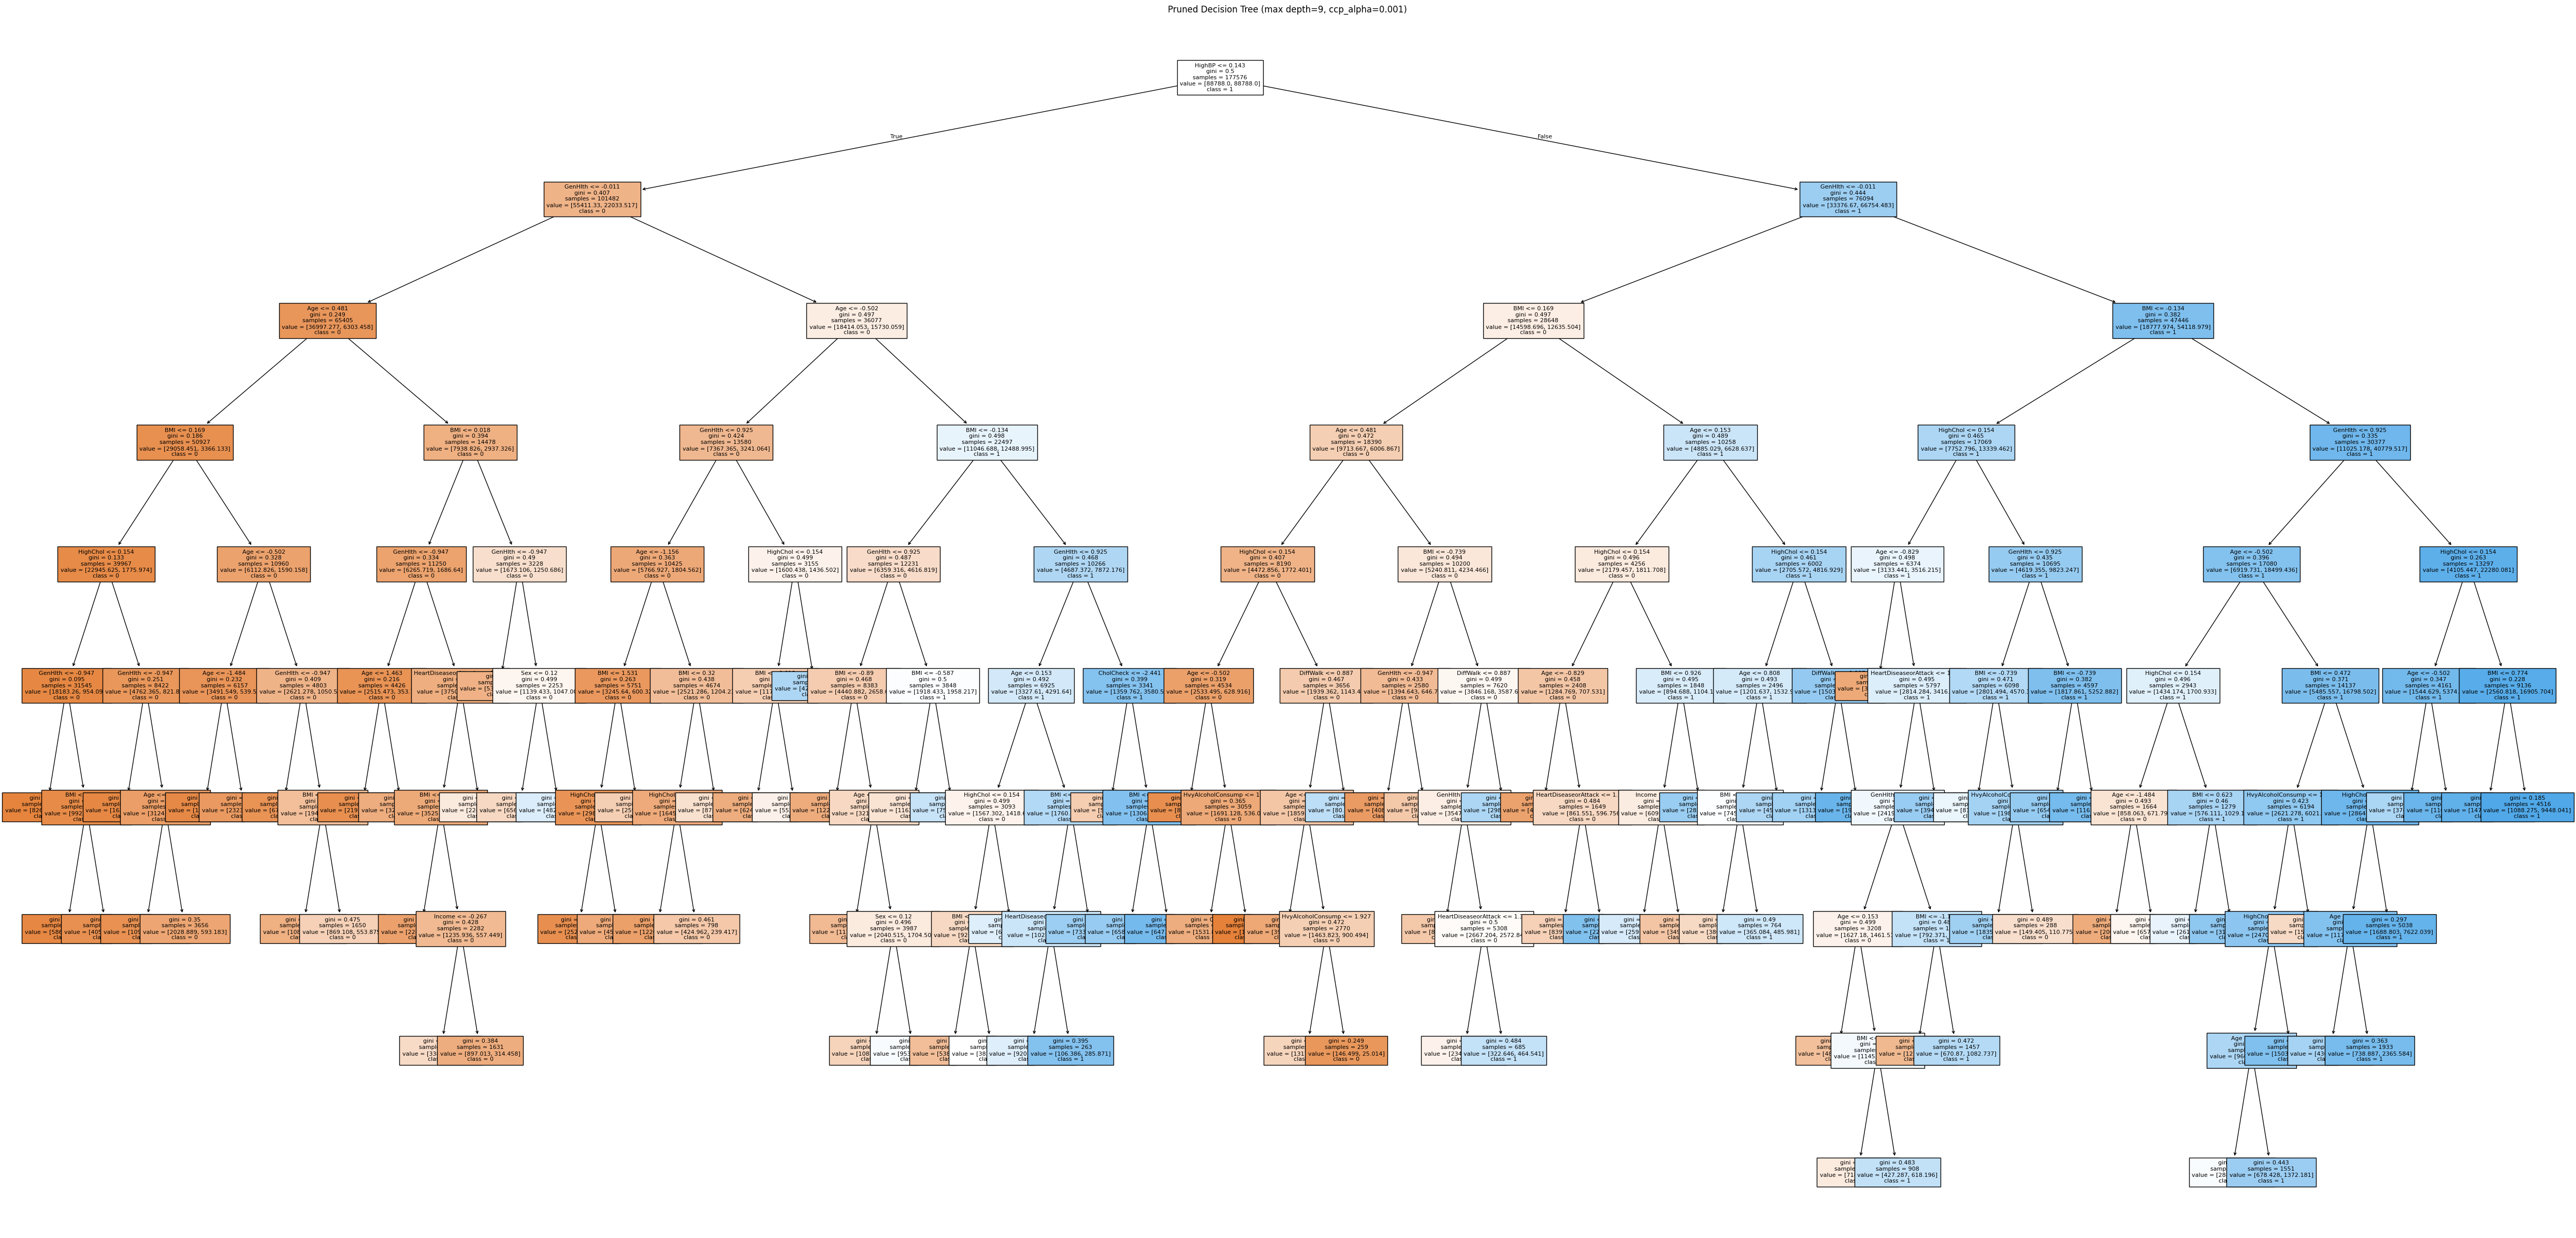

Accuracy: 0.7175
Profondità albero: 9
Numero di foglie: 95


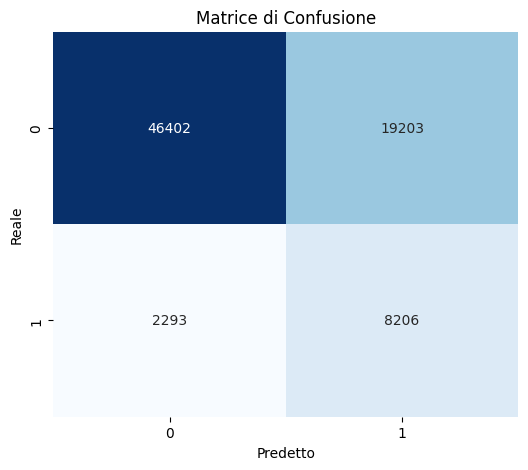


              precision    recall  f1-score   support

           0       0.95      0.71      0.81     65605
           1       0.30      0.78      0.43     10499

    accuracy                           0.72     76104
   macro avg       0.63      0.74      0.62     76104
weighted avg       0.86      0.72      0.76     76104



In [73]:
dt_pruned = DecisionTreeClassifier(
    random_state=42, class_weight="balanced", ccp_alpha=0.0001
)
dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)
print_tree(
    dt_pruned,
    dt_pruned.get_depth(),
    "Pruned Decision Tree (max depth=" + str(dt_pruned.get_depth()) + ", ccp_alpha=0.001)",
)
show_tree_metrics(dt_pruned, y_test, y_pred_pruned)

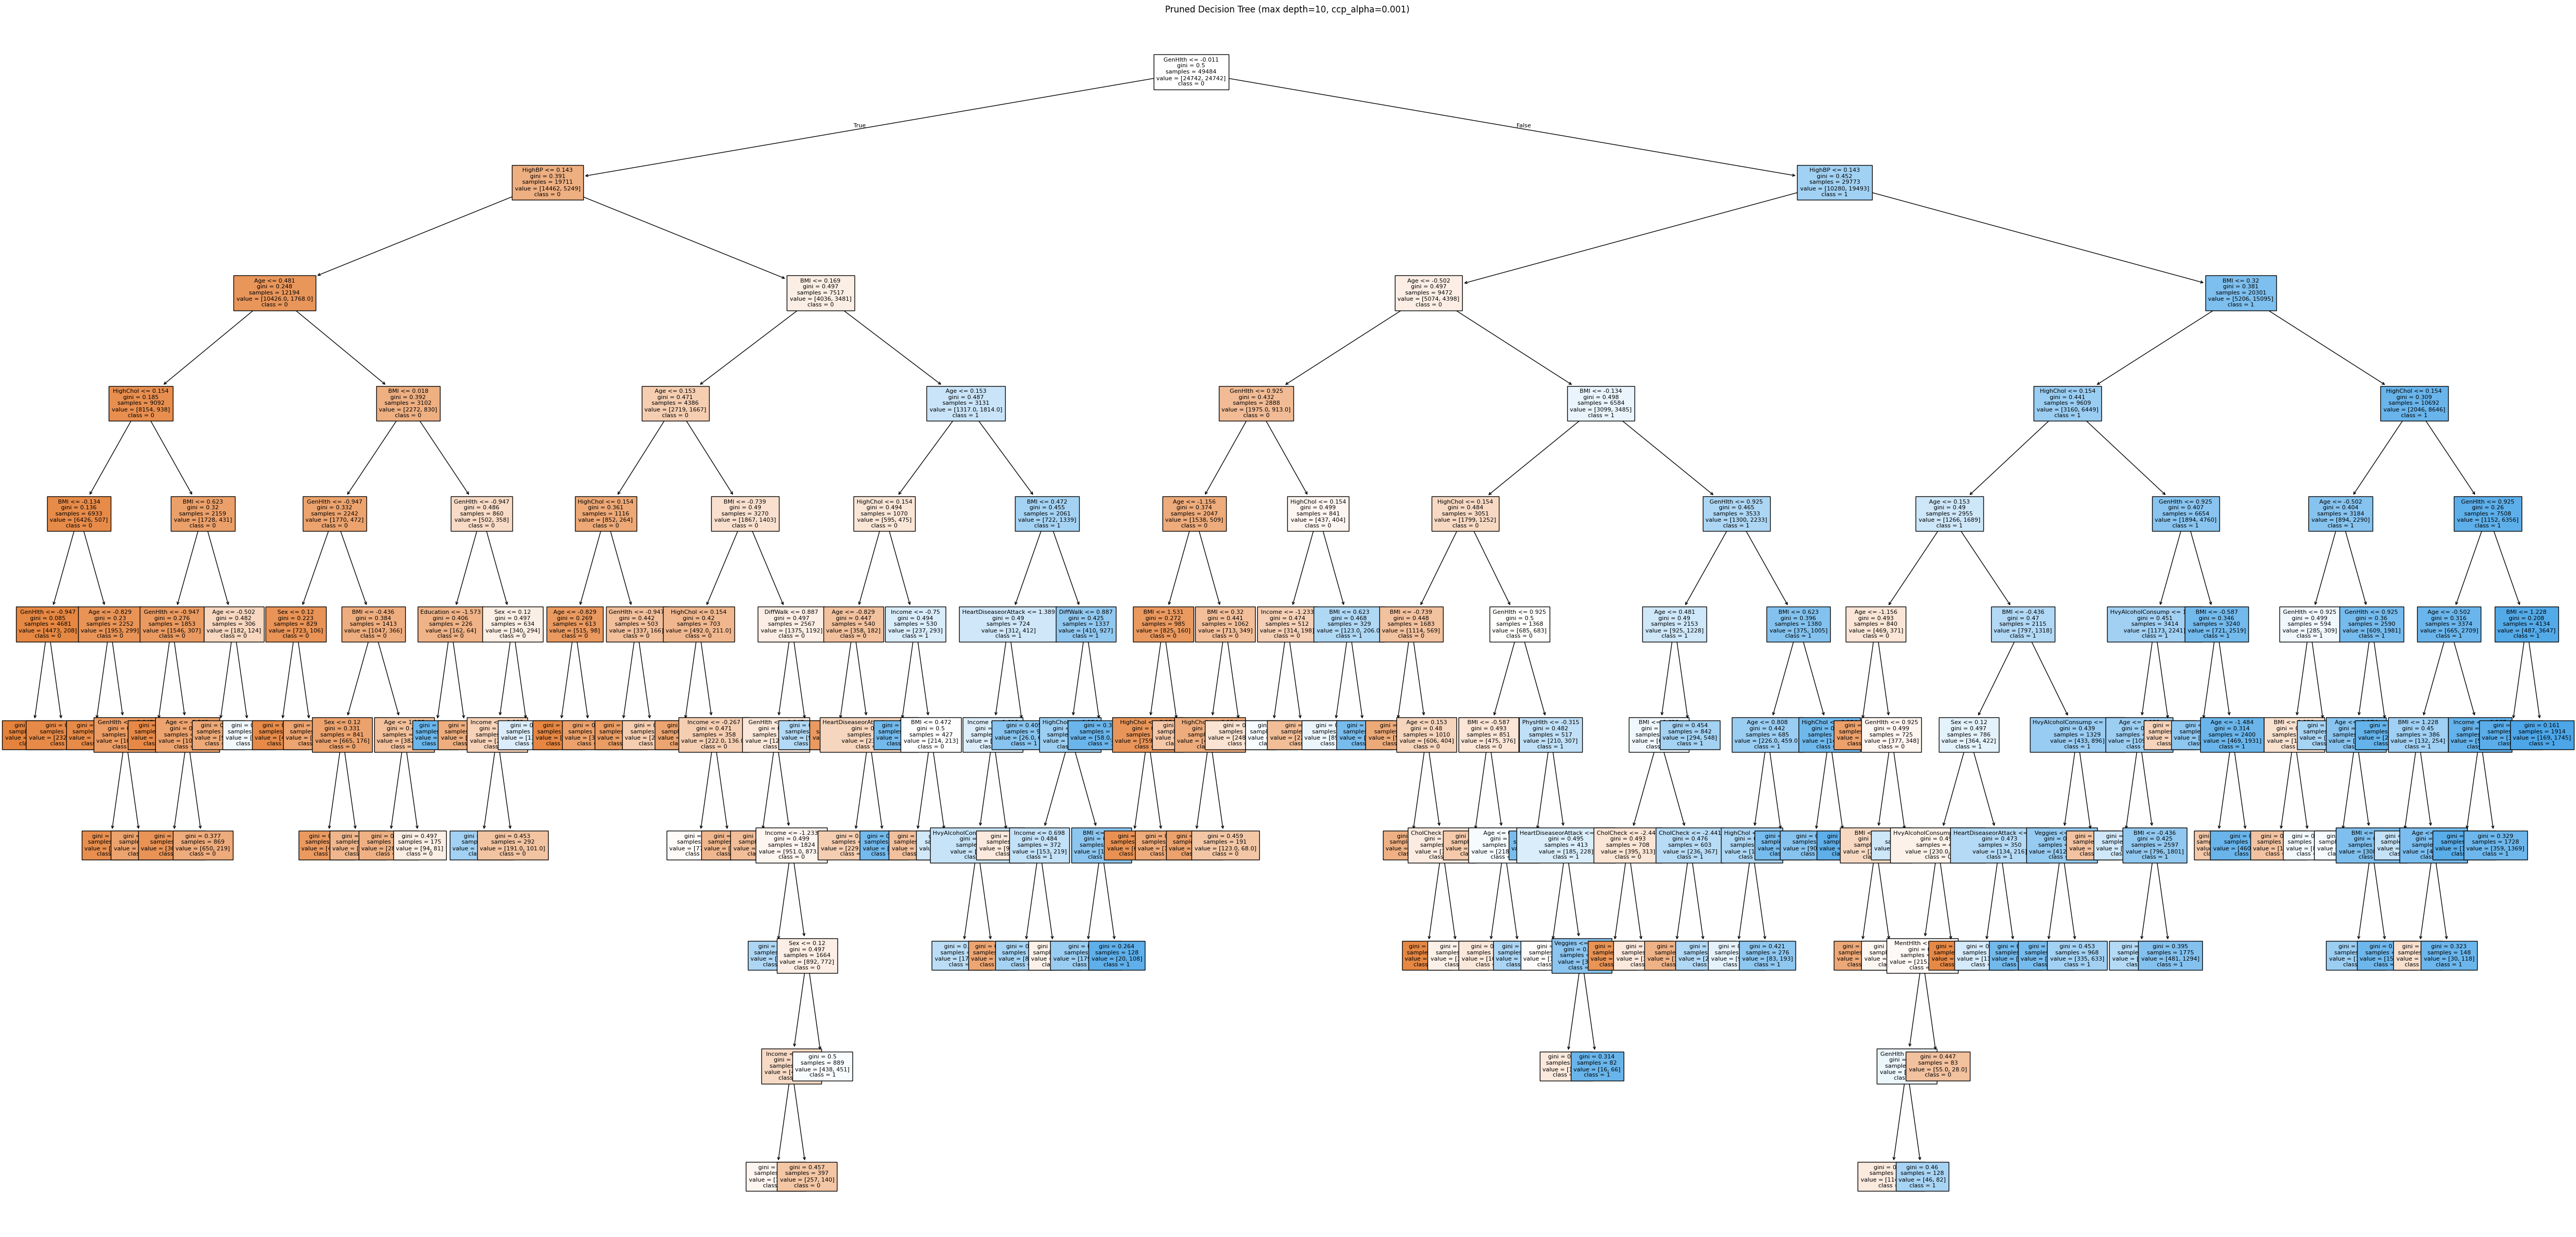

Accuracy: 0.6571
Profondità albero: 10
Numero di foglie: 114


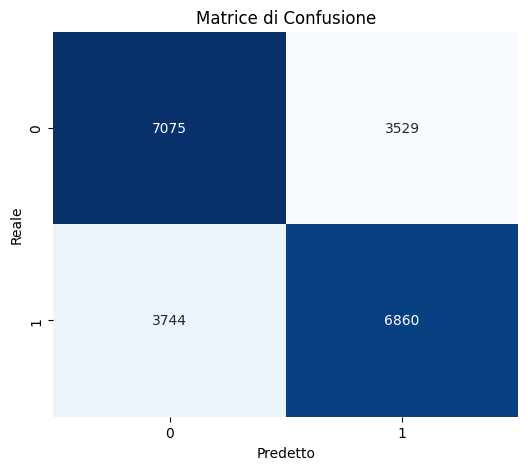


              precision    recall  f1-score   support

           0       0.65      0.67      0.66     10604
           1       0.66      0.65      0.65     10604

    accuracy                           0.66     21208
   macro avg       0.66      0.66      0.66     21208
weighted avg       0.66      0.66      0.66     21208



In [74]:
dt_pruned_bal = DecisionTreeClassifier(random_state=42, class_weight="balanced", ccp_alpha=0.0001)
dt_pruned_bal.fit(X_train_bal, y_train_bal)

y_pred_pruned_bal = dt_no_pruning_bal.predict(X_test_bal)

print_tree(dt_pruned_bal, dt_pruned_bal.get_depth(), "Pruned Decision Tree (max depth=" + str(dt_pruned_bal.get_depth()) + ", ccp_alpha=0.001)")
show_tree_metrics(dt_pruned_bal, y_test_bal, y_pred_pruned_bal)

## PCA

### No Pruning

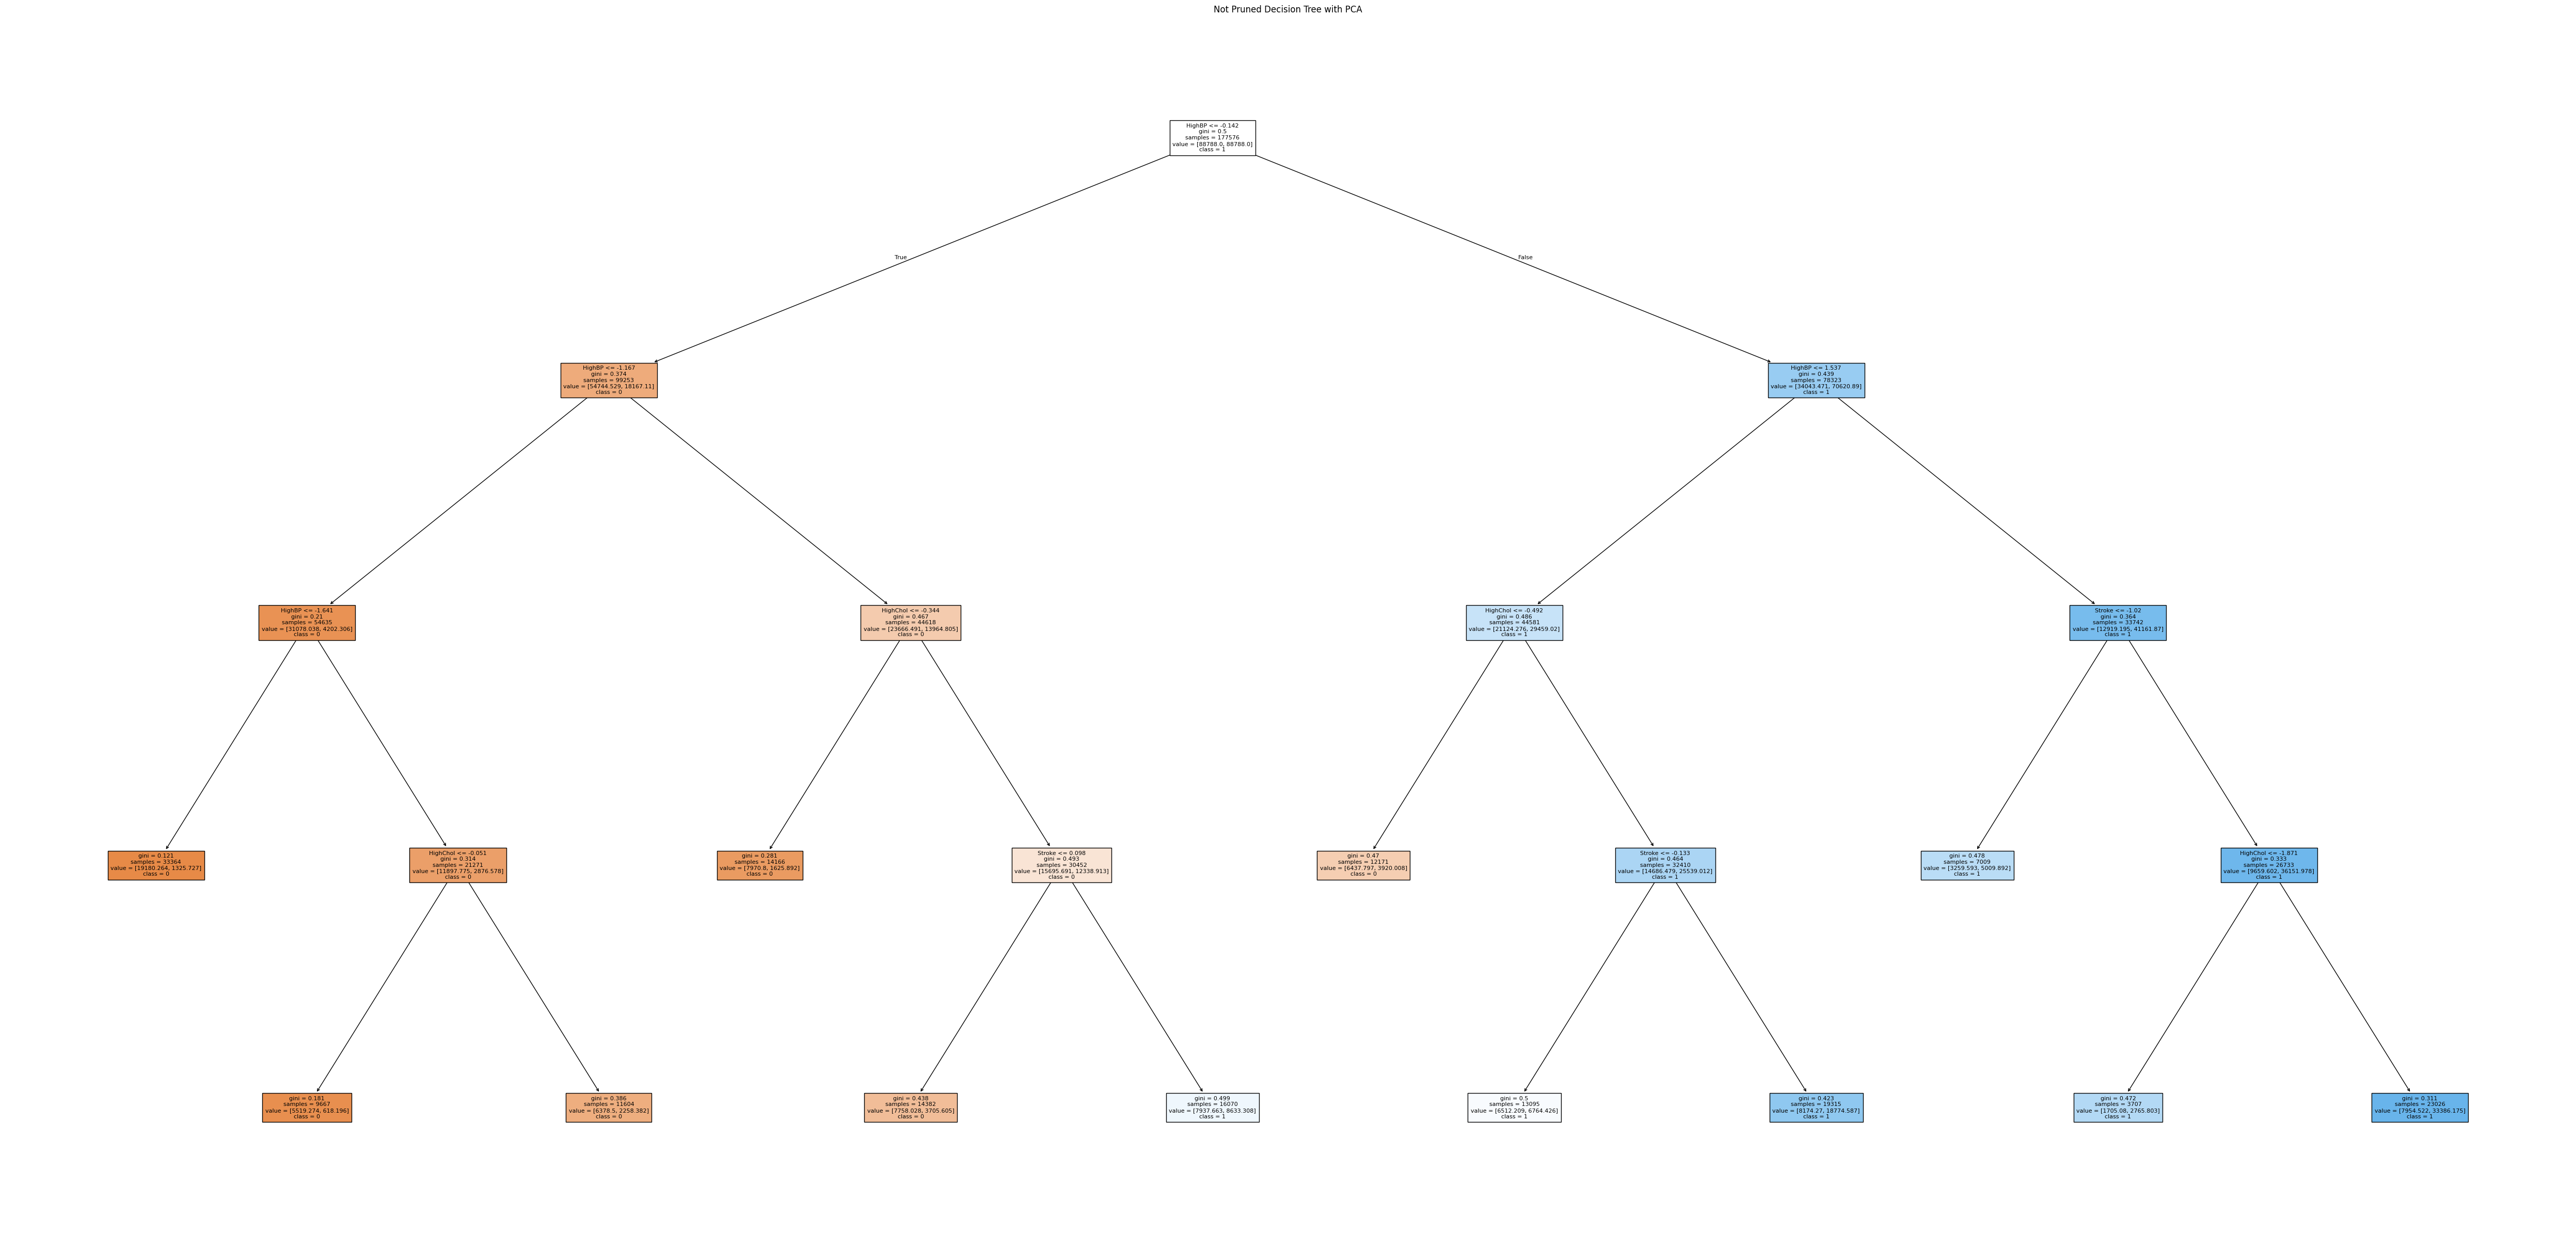

Accuracy: 0.6333
Profondità albero: 4
Numero di foglie: 12


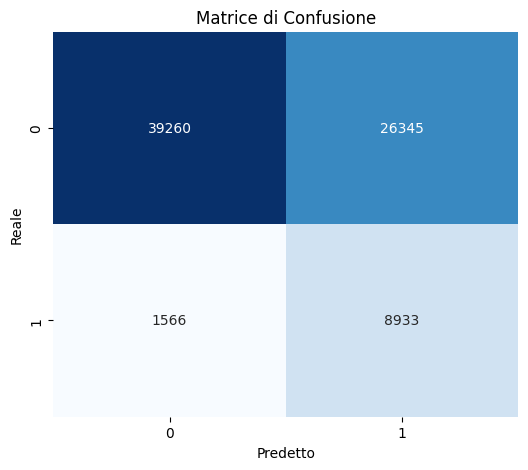


              precision    recall  f1-score   support

           0       0.96      0.60      0.74     65605
           1       0.25      0.85      0.39     10499

    accuracy                           0.63     76104
   macro avg       0.61      0.72      0.56     76104
weighted avg       0.86      0.63      0.69     76104



In [ ]:
dt_pca_no_pruned = DecisionTreeClassifier(
    random_state=42, class_weight="balanced", ccp_alpha=0.001
)
dt_pca_no_pruned.fit(X_train_pca, y_train_pca)

y_pred_no_pruned = dt_pca_no_pruned.predict(X_test_pca)
print_tree(dt_pca_no_pruned, 4, "Not Pruned Decision Tree with PCA")
show_tree_metrics(dt_pca_no_pruned, y_test_pca, y_pred_no_pruned)

### With Pruning

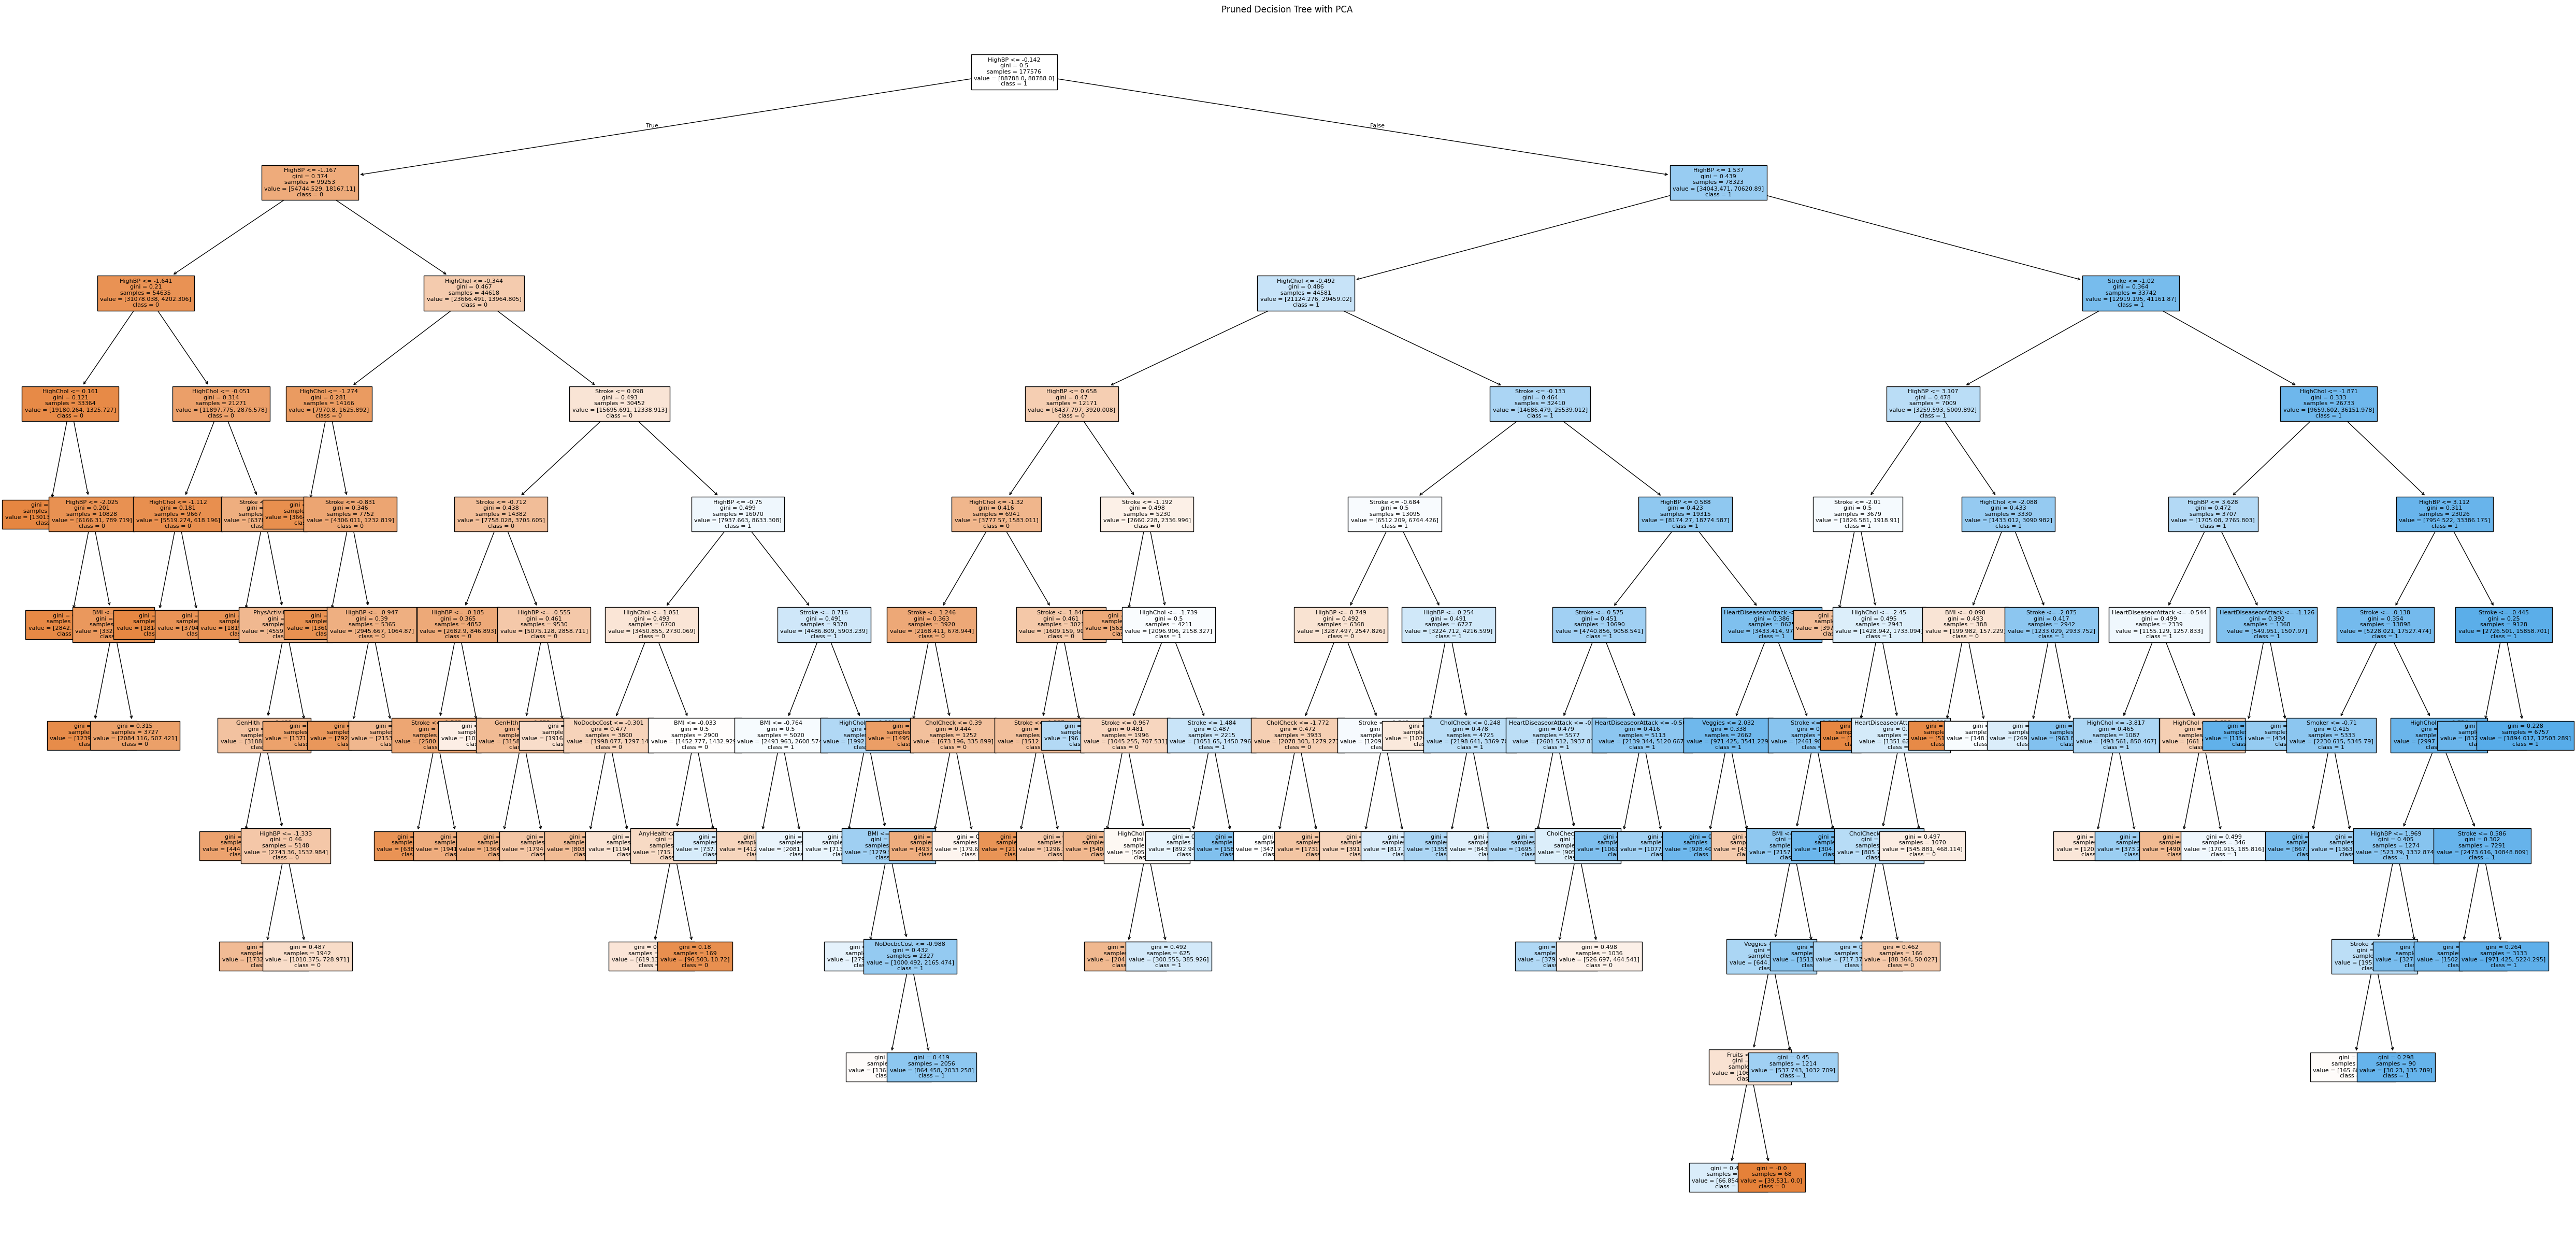

Accuracy: 0.6968
Profondità albero: 10
Numero di foglie: 87


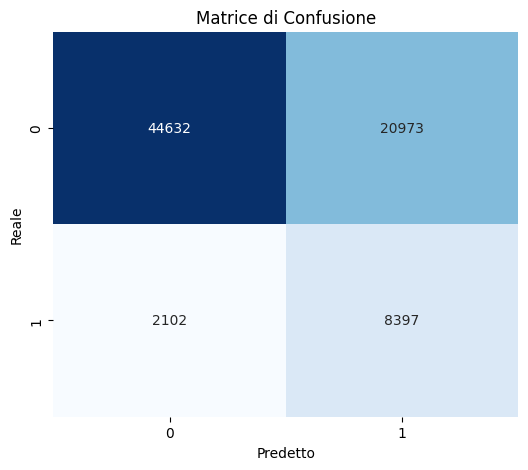


              precision    recall  f1-score   support

           0       0.96      0.68      0.79     65605
           1       0.29      0.80      0.42     10499

    accuracy                           0.70     76104
   macro avg       0.62      0.74      0.61     76104
weighted avg       0.86      0.70      0.74     76104



In [ ]:
dt_pca_pruned = DecisionTreeClassifier(
    random_state=42, class_weight="balanced", ccp_alpha=0.0001
)
dt_pca_pruned.fit(X_train_pca, y_train_pca)

y_pred_pruned = dt_pca_pruned.predict(X_test_pca)
print_tree(dt_pca_pruned, dt_pca_pruned.get_depth(), "Pruned Decision Tree with PCA")
show_tree_metrics(dt_pca_pruned, y_test_pca, y_pred_pruned)